# Yu-Gi-Oh! Card Dataset Exploratory Data Analysis

This notebook explores a scraped dataset of Yu-Gi-Oh! cards, then preprocesses it into a clean and modelling-ready frame.

> Source: https://www.kaggle.com/datasets/benedictusryugunawan/yu-gi-oh-cards-prices-dataset

# Import Library

In [1]:
import ast
import math
import os
import re
from collections import Counter
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import missingno as msno
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from wordcloud import WordCloud

In [2]:
DATA_RELATIVE = Path("data") / "yugioh_cards.csv"


def resolve_root(start: Path) -> Path:
    for folder in [start, *start.parents]:
        if (folder / DATA_RELATIVE).is_file():
            return folder
    for candidate in sorted(start.glob("*/data/yugioh_cards.csv")):
        return candidate.parent.parent
    raise FileNotFoundError(f"{DATA_RELATIVE} not found from {start} or its parents")


@dataclass
class Config:
    ROOT_DIR: Path = resolve_root(Path.cwd())
    DATA_FILE: Path = ROOT_DIR / DATA_RELATIVE
    OUTPUT_DIR: Path = ROOT_DIR / "output"
    SEED: int = 42


cfg = Config()
cfg.OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Root directory: {cfg.ROOT_DIR}")
print(f"Data file: {cfg.DATA_FILE}")
print(f"Output directory: {cfg.OUTPUT_DIR}")

Root directory: /home/ryz/data/collage/sem3/datmin/Repo/Week 4/makalah
Data file: /home/ryz/data/collage/sem3/datmin/Repo/Week 4/makalah/data/yugioh_cards.csv
Output directory: /home/ryz/data/collage/sem3/datmin/Repo/Week 4/makalah/output


# Get Dataset

In [3]:
df = pd.read_csv(cfg.DATA_FILE)
df.index = df["id"]
df.drop(columns=["id"], inplace=True)
df.head(5)

,name,type,frame_type,description,race,attribute,archetype,level,rank,link_value,...,image_url_small,tcgplayer_price,cardmarket_price,ebay_price,amazon_price,ban_tcg,ban_ocg,ban_goat,set_count,sets
id,,,,,,,,,,,,,,,,,,,,,
80181649,"""A Case for K9""",Spell Card,spell,"When this card is activated: You can add 1 ""K9...",Continuous,NaN,K9,NaN,NaN,NaN,...,https://images.ygoprodeck.com/images/cards_sma...,0.17,0.23,0.00,0.00,Limited,NaN,NaN,4,"[{'set_name': 'Justice Hunters', 'set_code': '..."
34541863,"""A"" Cell Breeding Device",Spell Card,spell,"During each of your Standby Phases, put 1 A-Co...",Continuous,NaN,Alien,NaN,NaN,NaN,...,https://images.ygoprodeck.com/images/cards_sma...,0.22,0.10,0.99,24.45,NaN,NaN,NaN,1,"[{'set_name': 'Force of the Breaker', 'set_cod..."
64163367,"""A"" Cell Incubator",Spell Card,spell,Each time an A-Counter(s) is removed from play...,Continuous,NaN,Alien,NaN,NaN,NaN,...,https://images.ygoprodeck.com/images/cards_sma...,0.22,0.12,1.25,0.50,NaN,NaN,NaN,1,"[{'set_name': ""Gladiator's Assault"", 'set_code..."
91231901,"""A"" Cell Recombination Device",Spell Card,spell,Target 1 face-up monster on the field; send 1 ...,Quick-Play,NaN,Alien,NaN,NaN,NaN,...,https://images.ygoprodeck.com/images/cards_sma...,0.13,0.06,0.99,0.50,NaN,NaN,NaN,1,"[{'set_name': 'Invasion: Vengeance', 'set_code..."
73262676,"""A"" Cell Scatter Burst",Spell Card,spell,"Select 1 face-up ""Alien"" monster you control. ...",Quick-Play,NaN,Alien,NaN,NaN,NaN,...,https://images.ygoprodeck.com/images/cards_sma...,0.16,0.14,2.00,9.76,NaN,NaN,NaN,1,"[{'set_name': 'Strike of Neos', 'set_code': 'S..."


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 14533 entries, 80181649 to 76080032
Data columns (total 23 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   name              14533 non-null  object 
 1   type              14533 non-null  object 
 2   frame_type        14533 non-null  object 
 3   description       14533 non-null  object 
 4   race              14530 non-null  object 
 5   attribute         9343 non-null   object 
 6   archetype         8786 non-null   object 
 7   level             8978 non-null   float64
 8   rank              0 non-null      float64
 9   link_value        473 non-null    float64
 10  atk               9343 non-null   float64
 11  def               8870 non-null   float64
 12  image_url         14533 non-null  object 
 13  image_url_small   14533 non-null  object 
 14  tcgplayer_price   14533 non-null  float64
 15  cardmarket_price  14533 non-null  float64
 16  ebay_price        14533 non-null  f

The raw file has 24 columns and three of them are dropped right away:

- `rank` is empty in every row, so it carries no information even though an XYZ monster does have a rank in the game.
- `image_url` and `image_url_small` only hold links and are not used in this analysis.

The remaining columns are kept for the exploratory part. The problems that the `df.info()` output and the missing value analysis reveal, placeholder prices, negative combat statistics and a `sets` column that stores a Python list as plain text, are fixed in the Data Preprocessing section at the end of this notebook.

In [5]:
df.drop(columns=["image_url", "image_url_small", "rank"], inplace=True)
print(f"Dataframe shape after dropping columns: {df.shape}")
print(f"Columns after dropping: {df.columns.tolist()}")
print(f"Number of unique card names: {df['name'].nunique()}")

Dataframe shape after dropping columns: (14533, 20)
Columns after dropping: ['name', 'type', 'frame_type', 'description', 'race', 'attribute', 'archetype', 'level', 'link_value', 'atk', 'def', 'tcgplayer_price', 'cardmarket_price', 'ebay_price', 'amazon_price', 'ban_tcg', 'ban_ocg', 'ban_goat', 'set_count', 'sets']
Number of unique card names: 14533


# Exploratory Data Analysis

## Check Missing Values

/home/ryz/miniforge3/envs/dsml/lib/python3.10/site-packages/missingno/missingno.py:61: UserWarning: Plotting a sparkline on an existing axis is not currently supported. To remove this warning, set sparkline=False.
  warnings.warn(


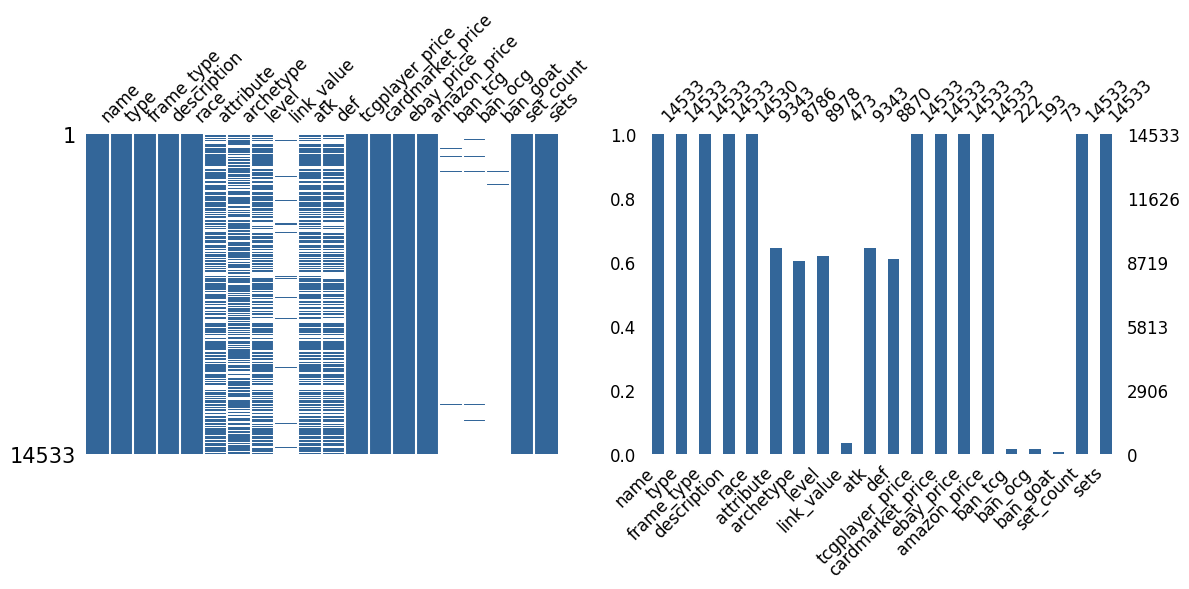

In [6]:

fig,ax = plt.subplots(1,2,figsize=(12,6))
ax = ax.flatten()

msno.matrix(df, ax=ax[0], fontsize=12, color=(0.2, 0.4, 0.6))
msno.bar(df, ax=ax[1], fontsize=12, color=(0.2, 0.4, 0.6))
plt.tight_layout()

The matrix shows a large amount of missing data, and most of it is structural rather than random: a card type simply does not have certain features. A `Spell Card` for example has no attack and no defence, so `atk` and `def` are empty for every spell card.

<Axes: >

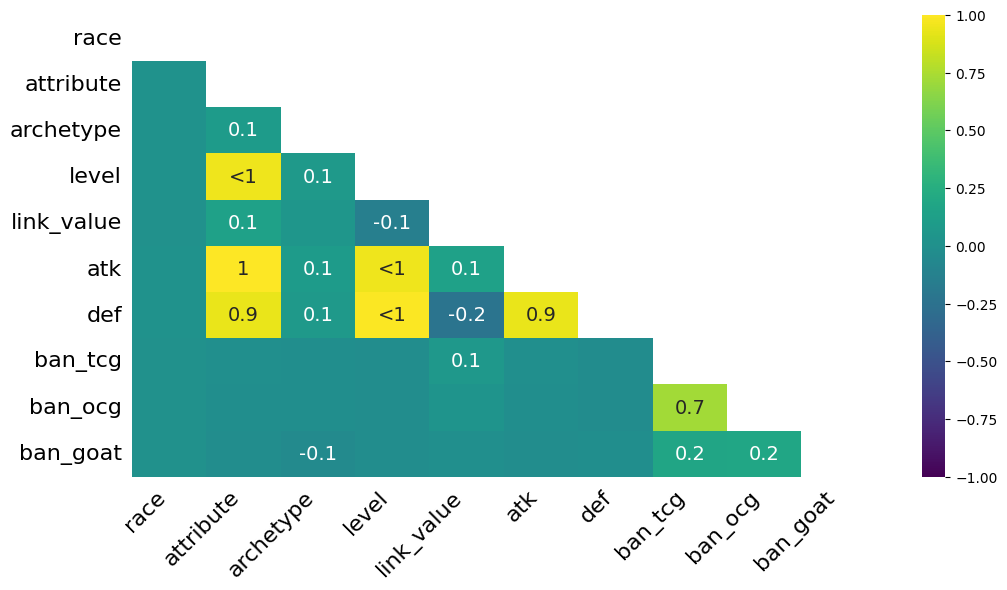

In [7]:
msno.heatmap(df, figsize=(12,6), cmap="viridis")

Several columns are missing together, and the heatmap shows this as high correlation between the missing blocks. One obvious block is `level` with `atk` and `def`, because spell and trap cards do not have any of them.

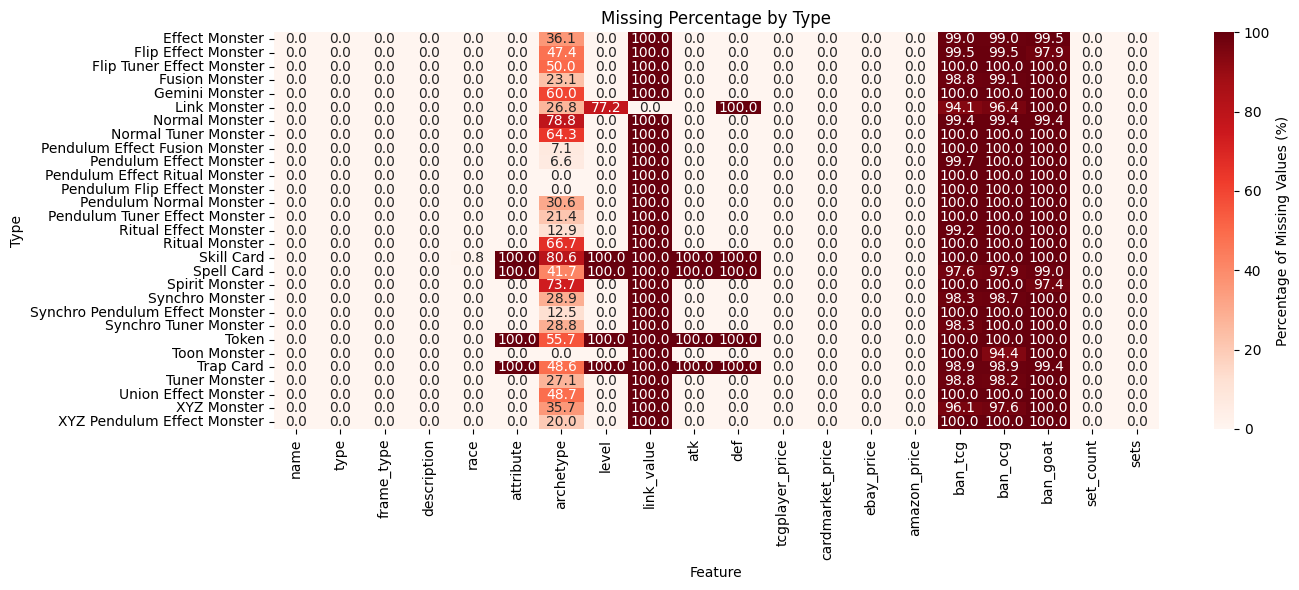

In [8]:
missing_by_type = df.isna().groupby(df["type"], observed=True).mean() * 100

plt.figure(figsize=(14, 6))
sns.heatmap(
    missing_by_type,
    annot=True,
    fmt=".1f",
    cmap="Reds",
    cbar_kws={"label": "Percentage of Missing Values (%)"}
)

plt.title("Missing Percentage by Type")
plt.ylabel("Type")
plt.xlabel("Feature")
plt.tight_layout()
plt.savefig(cfg.OUTPUT_DIR / "missing_by_type.png", dpi=150, bbox_inches="tight")
plt.show()

The percentage of missing values depends almost completely on the card type. The ban list columns are mostly empty for a different reason: only a banned or limited card carries a status, and such cards are rare.

In [9]:
num_cols = df.select_dtypes(include=[int, float]).columns.tolist()
cat_cols = df.select_dtypes(exclude=[int, float]).columns.tolist()

print(f"Numerical columns: {num_cols}")
print(f"Categorical columns: {cat_cols}")

Numerical columns: ['level', 'link_value', 'atk', 'def', 'tcgplayer_price', 'cardmarket_price', 'ebay_price', 'amazon_price', 'set_count']
Categorical columns: ['name', 'type', 'frame_type', 'description', 'race', 'attribute', 'archetype', 'ban_tcg', 'ban_ocg', 'ban_goat', 'sets']


## Numeric Analysis

## Distributions (Histogram and KDE)

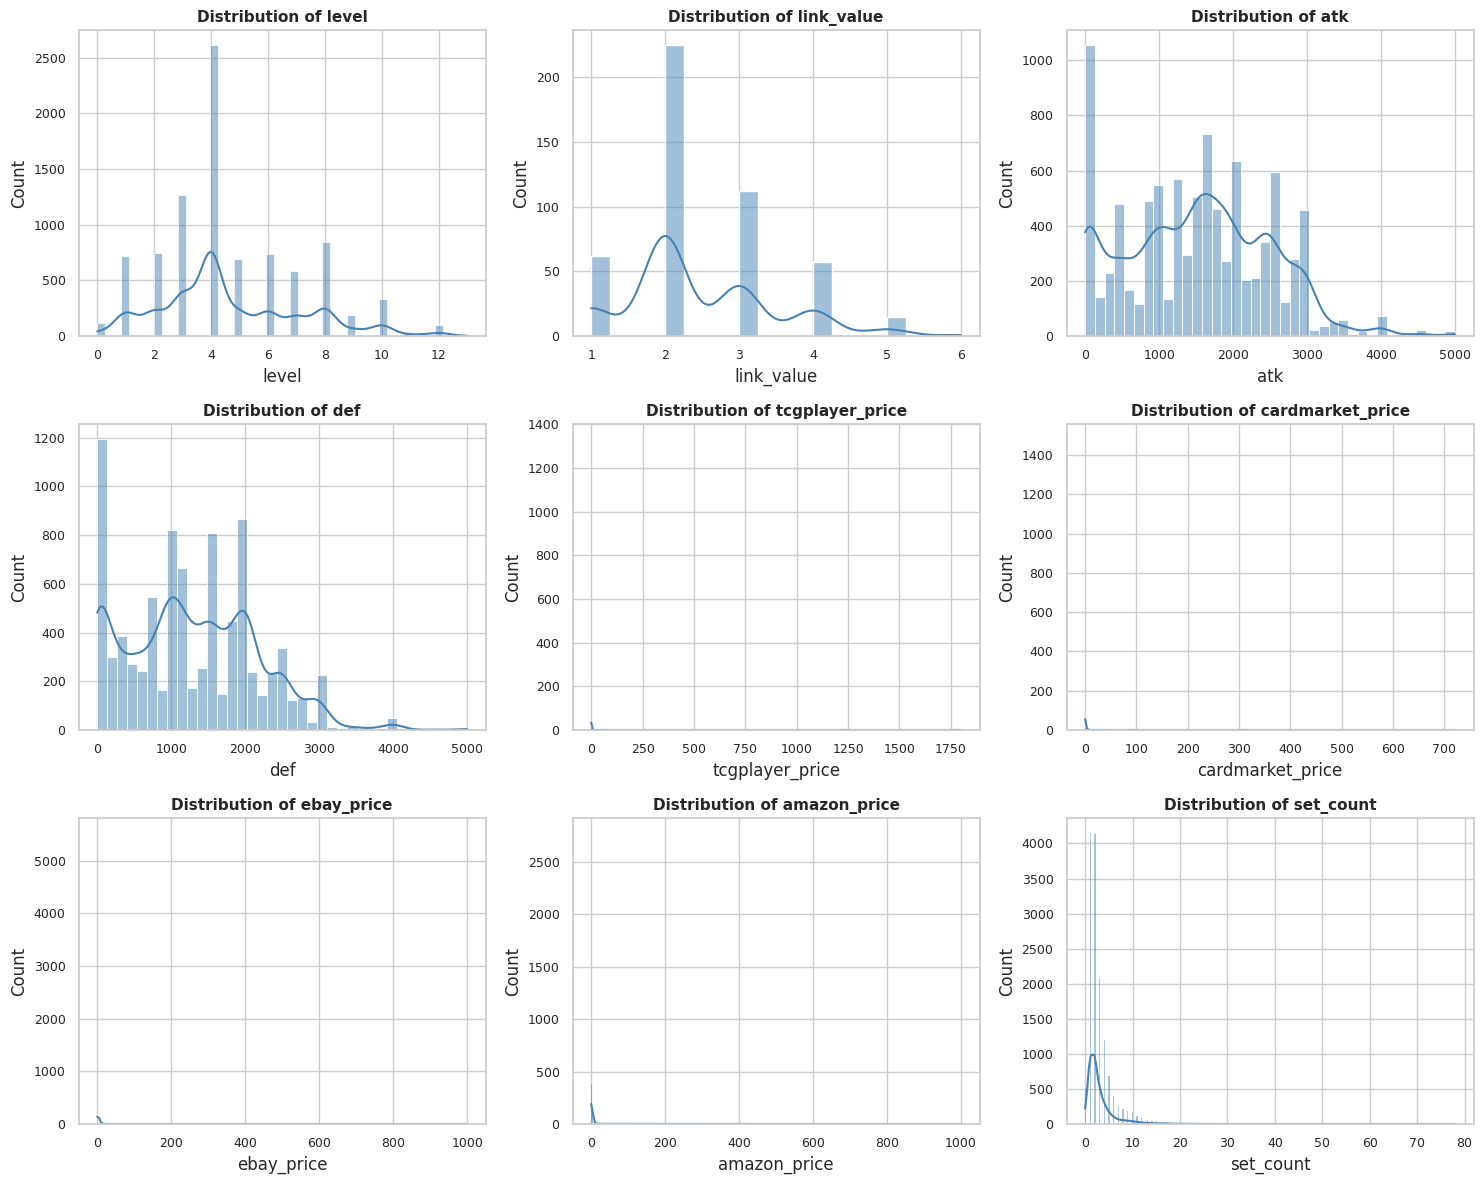

,count,mean,std,min,25%,50%,75%,max
level,8978.0,4.66,2.50,0.0,3.00,4.00,6.00,13.00
link_value,473.0,2.46,1.00,1.0,2.00,2.00,3.00,6.00
atk,9343.0,1519.82,963.11,-1.0,800.00,1500.00,2200.00,5000.00
def,8870.0,1287.50,883.09,-1.0,600.00,1200.00,2000.00,5000.00
tcgplayer_price,14533.0,1.16,18.82,0.0,0.12,0.19,0.33,1800.00
cardmarket_price,14533.0,0.85,10.36,0.0,0.06,0.12,0.25,720.91
ebay_price,14533.0,3.84,29.45,0.0,0.99,0.99,2.49,999.99
amazon_price,14533.0,3.52,20.65,0.0,0.25,0.66,1.73,999.99
set_count,14533.0,3.06,3.49,0.0,1.00,2.00,4.00,78.00


Skewness (>>1 = heavy right tail):


tcgplayer_price     68.77
cardmarket_price    44.97
ebay_price          27.26
amazon_price        26.29
set_count            5.54
link_value           0.74
level                0.63
def                  0.39
atk                  0.21
dtype: float64

In [10]:

sns.set_theme(style="whitegrid")
n_cols_grid = 3
n_rows_grid = math.ceil(len(num_cols) / n_cols_grid)

fig, axes = plt.subplots(n_rows_grid, n_cols_grid, figsize=(15, 12))
axes = axes.flatten()

for ax, col in zip(axes, num_cols):
    sns.histplot(df[col].dropna(), kde=True, ax=ax, color="steelblue", edgecolor="white")
    ax.set_title(f"Distribution of {col}", fontsize=11, fontweight="bold")
    ax.set_xlabel(col)
    ax.tick_params(labelsize=9)

for ax in axes[len(num_cols):]:
    ax.set_visible(False)

plt.tight_layout()
plt.savefig(cfg.OUTPUT_DIR / "numeric_hist_kde.png", dpi=150, bbox_inches="tight")
plt.show()

display(df[num_cols].describe().T.round(2))
print("Skewness (>>1 = heavy right tail):")
display(df[num_cols].skew(numeric_only=True).sort_values(ascending=False).round(2))


Two observations come out of the histograms and the summary table:

1. The four price columns are extremely right skewed, with a skewness between 26 and 69 and a maximum of $1,800 against a median of $0.19.
2. The combat statistics are roughly bell shaped, which fits a game with cost limited stat budgets.

The same nine columns are therefore plotted again as box plots, violin plots, ECDF curves and log scaled histograms.

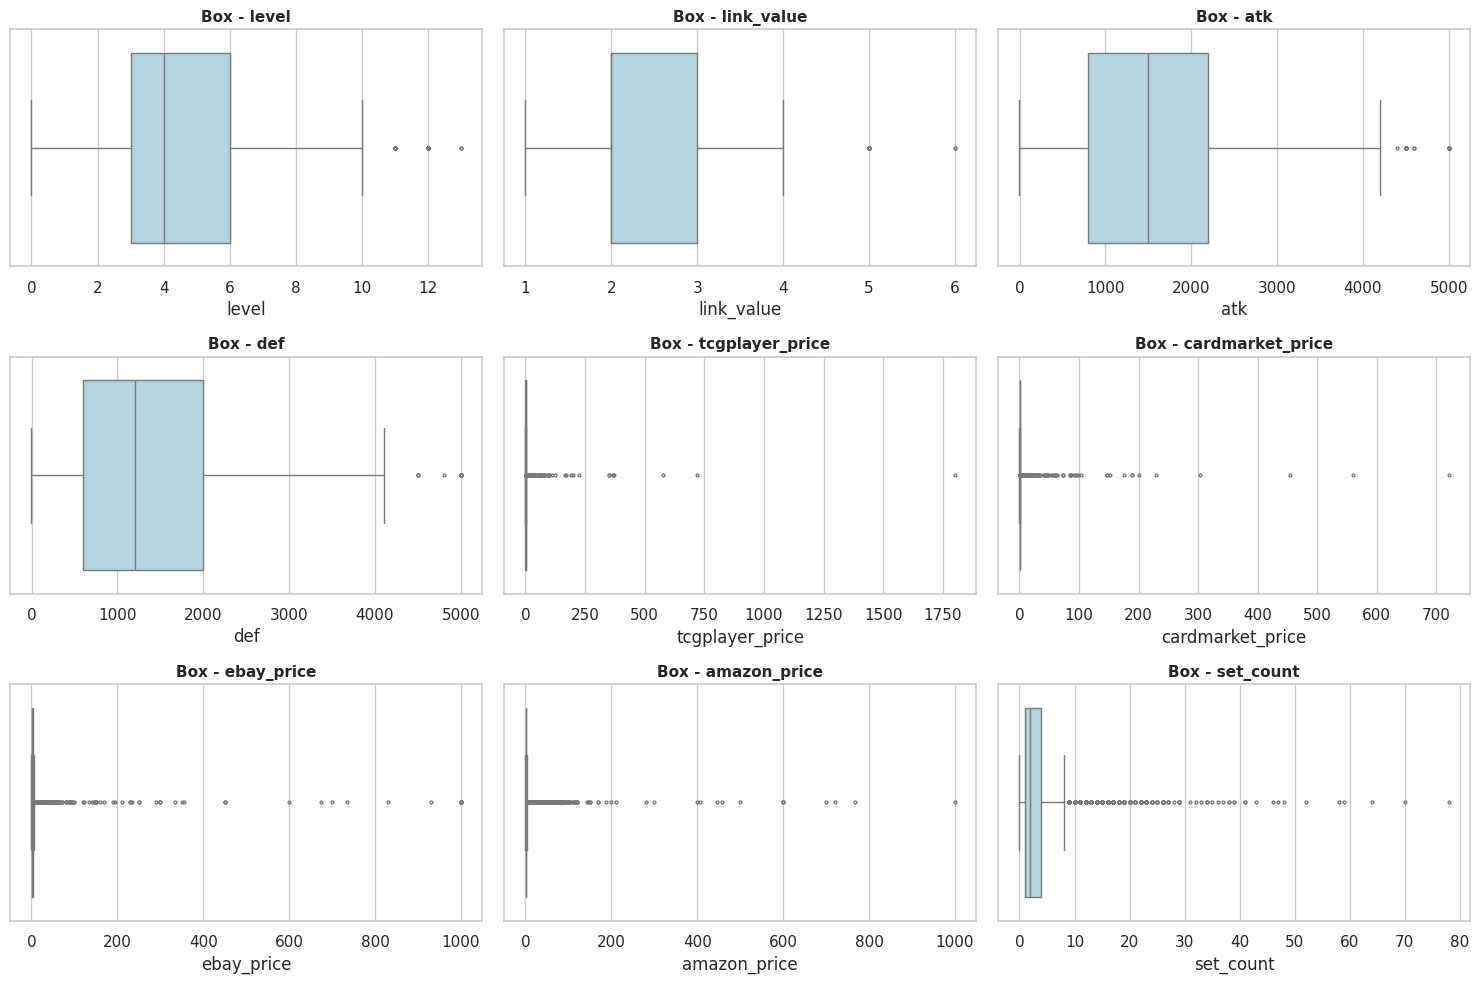

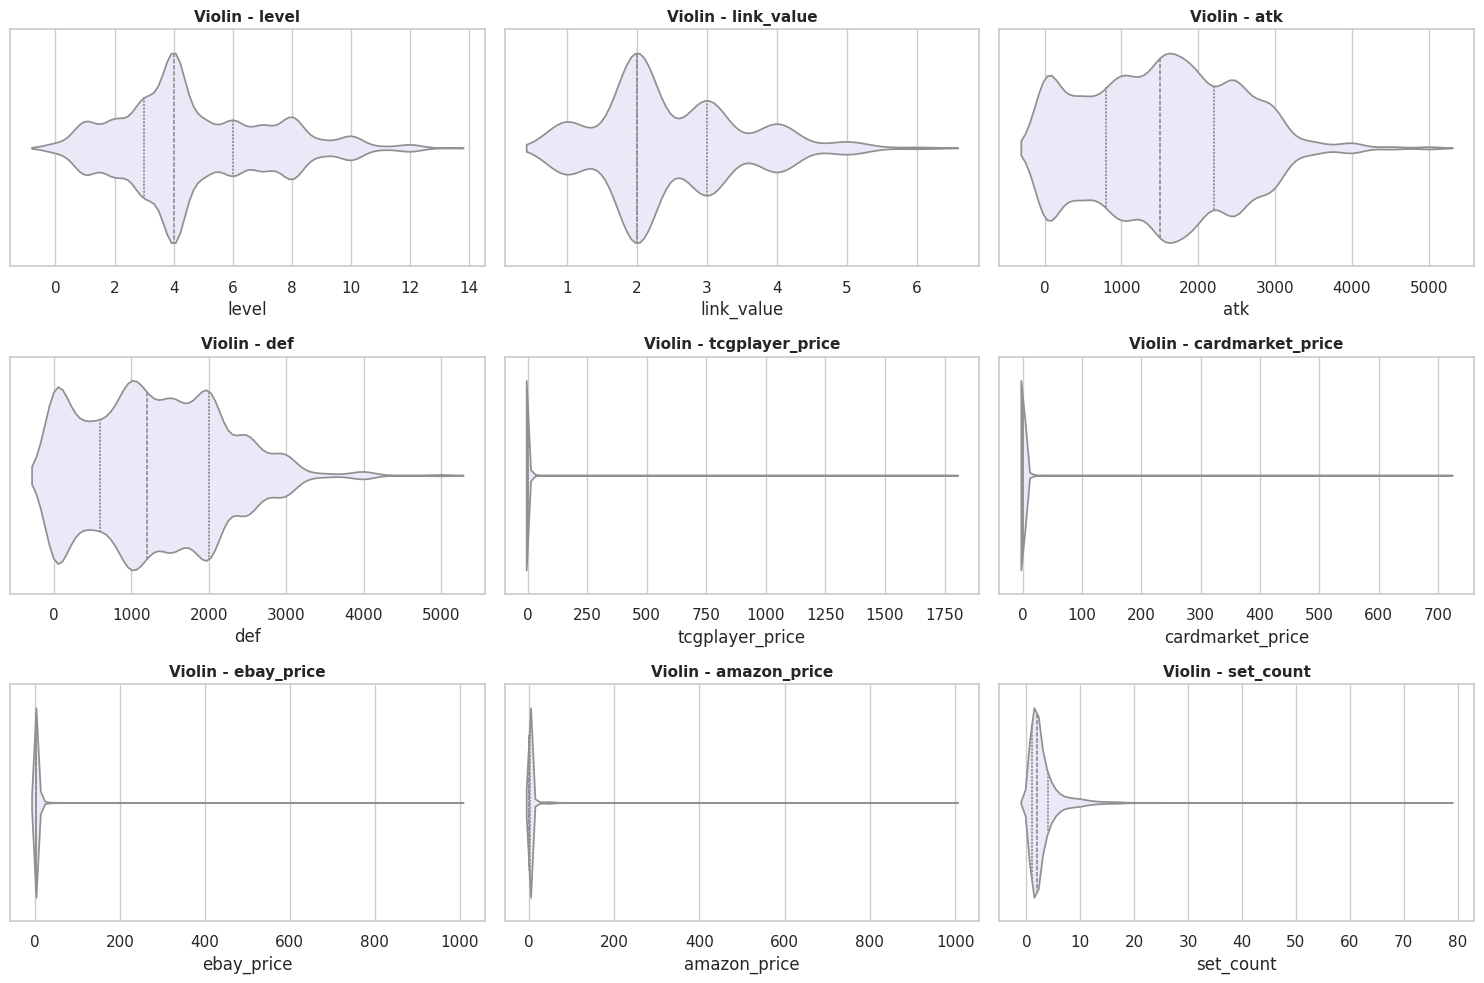

In [11]:
fig, axes = plt.subplots(3, 3, figsize=(15, 10))
axes = axes.flatten()
for ax, col in zip(axes, num_cols):
    sns.boxplot(x=df[col].dropna(), ax=ax, color="lightblue", fliersize=2)
    ax.set_title(f"Box - {col}", fontsize=11, fontweight="bold")
plt.tight_layout()
plt.savefig(cfg.OUTPUT_DIR / "numeric_box.png", dpi=150, bbox_inches="tight")
plt.show()

fig, axes = plt.subplots(3, 3, figsize=(15, 10))
axes = axes.flatten()
for ax, col in zip(axes, num_cols):
    sns.violinplot(x=df[col].dropna(), ax=ax, color="lavender", inner="quartile")
    ax.set_title(f"Violin - {col}", fontsize=11, fontweight="bold")
plt.tight_layout()
plt.savefig(cfg.OUTPUT_DIR / "numeric_violin.png", dpi=150, bbox_inches="tight")
plt.show()


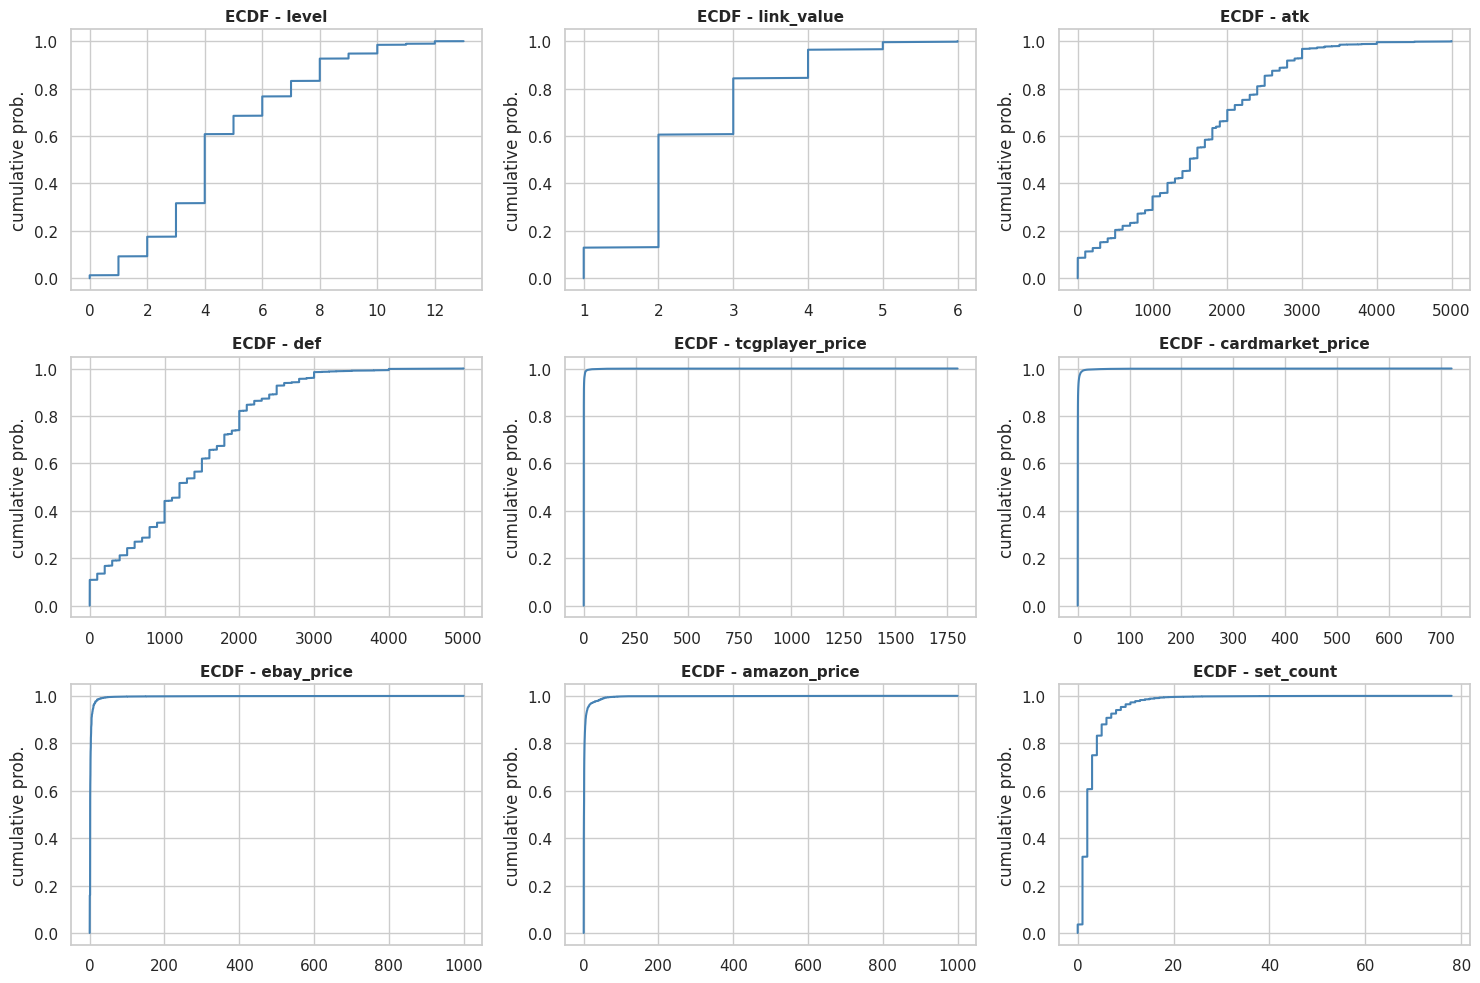

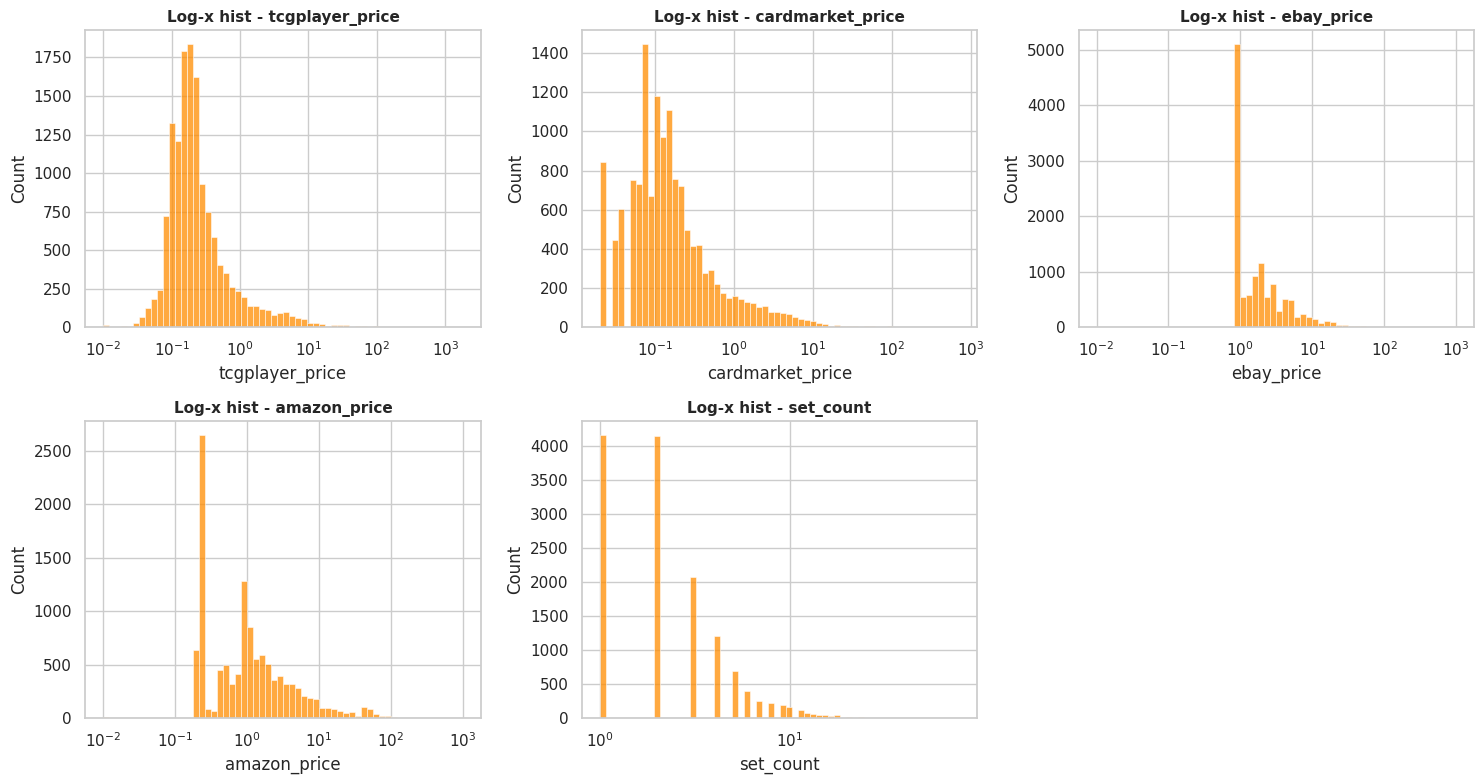

In [12]:
fig, axes = plt.subplots(3, 3, figsize=(15, 10))
axes = axes.flatten()
for ax, col in zip(axes, num_cols):
    s = df[col].dropna().sort_values()
    ax.plot(s.values, np.linspace(0, 1, len(s)), color="steelblue", lw=1.5)
    ax.set_title(f"ECDF - {col}", fontsize=11, fontweight="bold")
    ax.set_ylabel("cumulative prob.")
plt.tight_layout()
plt.savefig(cfg.OUTPUT_DIR / "numeric_ecdf.png", dpi=150, bbox_inches="tight")
plt.show()

skewed = ["tcgplayer_price", "cardmarket_price", "ebay_price", "amazon_price", "set_count"]
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for ax, col in zip(axes, skewed):
    s = df[col].dropna()
    sns.histplot(s[s > 0], bins=60, log_scale=True, ax=ax, color="darkorange", edgecolor="white")
    ax.set_title(f"Log-x hist - {col}", fontsize=11, fontweight="bold")
axes[-1].set_visible(False)
plt.tight_layout()
plt.savefig(cfg.OUTPUT_DIR / "numeric_loghist.png", dpi=150, bbox_inches="tight")
plt.show()


`atk` with a median of 1,500 and `def` with a median of 1,200 are mound shaped around the usual playable stat lines. `level` piles up on 3, 4, 7 and 8, and `link_value` is discrete between 1 and 6. All four price columns collapse near zero, with medians between $0.12 and $0.99 and a long tail of collectible cards, which is why every price plot needs a log or ECDF treatment and why the mean sits far above the median.

## Correlation Plot (Pearson and Spearman)

Pearson measures linear agreement and is sensitive to whale prices, while Spearman measures rank agreement and stays robust. `level` and `link_value` are mutually exclusive mechanics, because a Link monster has no level, so their pairwise correlation is NaN by construction. That blank cell is expected and not a bug.

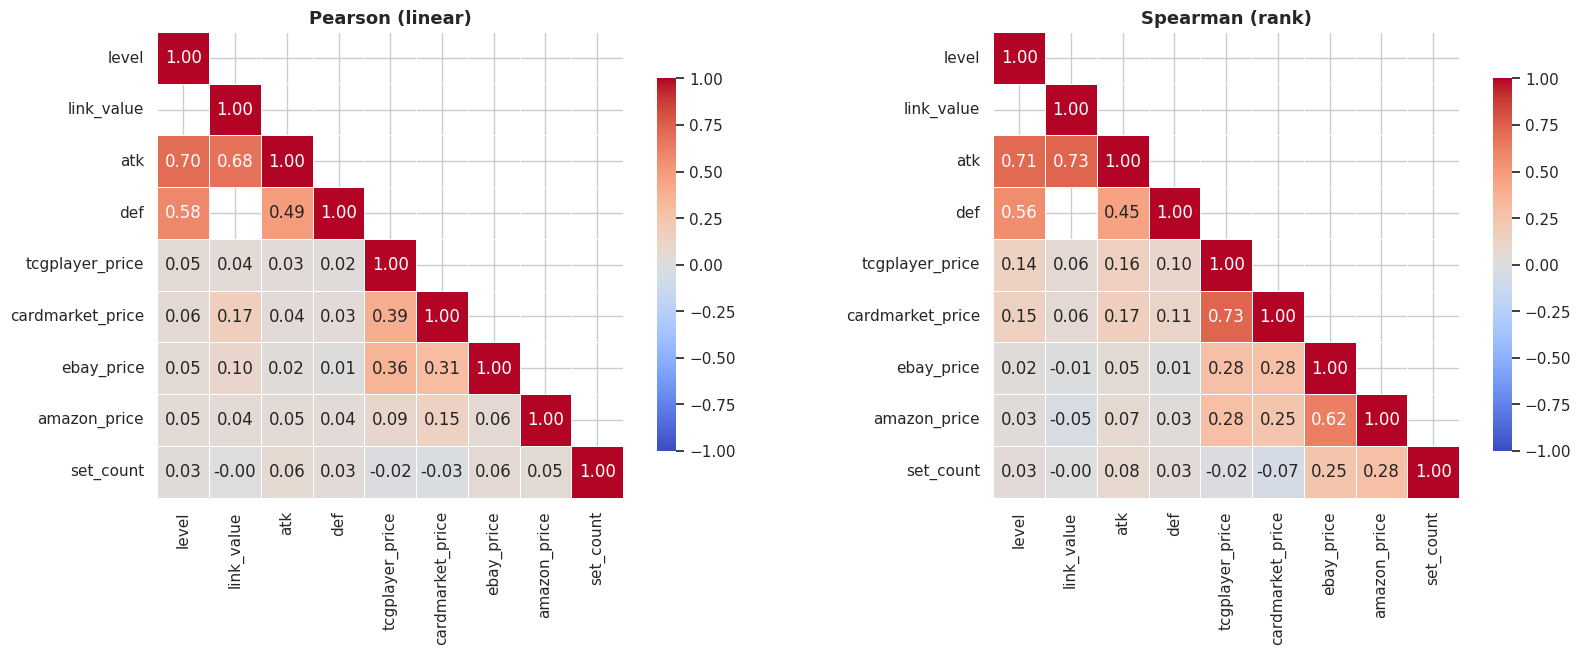

Top-10 absolute Pearson pairs (off-diagonal):
atk               level               0.698
                  link_value          0.676
def               level               0.579
                  atk                 0.491
cardmarket_price  tcgplayer_price     0.395
ebay_price        tcgplayer_price     0.356
                  cardmarket_price    0.306
cardmarket_price  link_value          0.165
amazon_price      cardmarket_price    0.148
ebay_price        link_value          0.098

Top-10 absolute Spearman pairs (off-diagonal):
atk               link_value          0.734
cardmarket_price  tcgplayer_price     0.728
atk               level               0.713
amazon_price      ebay_price          0.619
def               level               0.556
                  atk                 0.455
ebay_price        cardmarket_price    0.284
amazon_price      tcgplayer_price     0.282
set_count         amazon_price        0.282
ebay_price        tcgplayer_price     0.275


In [13]:
corr_pearson = df[num_cols].corr(method="pearson")
corr_spearman = df[num_cols].corr(method="spearman")

fig, axes = plt.subplots(1, 2, figsize=(17, 6.5))
mask = np.triu(np.ones_like(corr_pearson, dtype=bool), k=1)
for ax, corr, title in zip(axes, [corr_pearson, corr_spearman], ["Pearson (linear)", "Spearman (rank)"]):
    sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1,
                square=True, linewidths=.5, cbar_kws={"shrink": .8}, ax=ax)
    ax.set_title(title, fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(cfg.OUTPUT_DIR / "numeric_corr.png", dpi=150, bbox_inches="tight")
plt.show()

print("Top-10 absolute Pearson pairs (off-diagonal):")
tmp = corr_pearson.where(np.tril(np.ones_like(corr_pearson, dtype=bool), k=-1)).stack()
print((tmp.reindex(tmp.abs().sort_values(ascending=False).index).head(10)).round(3).to_string())
print("\nTop-10 absolute Spearman pairs (off-diagonal):")
tmp_s = corr_spearman.where(np.tril(np.ones_like(corr_spearman, dtype=bool), k=-1)).stack()
print((tmp_s.reindex(tmp_s.abs().sort_values(ascending=False).index).head(10)).round(3).to_string())


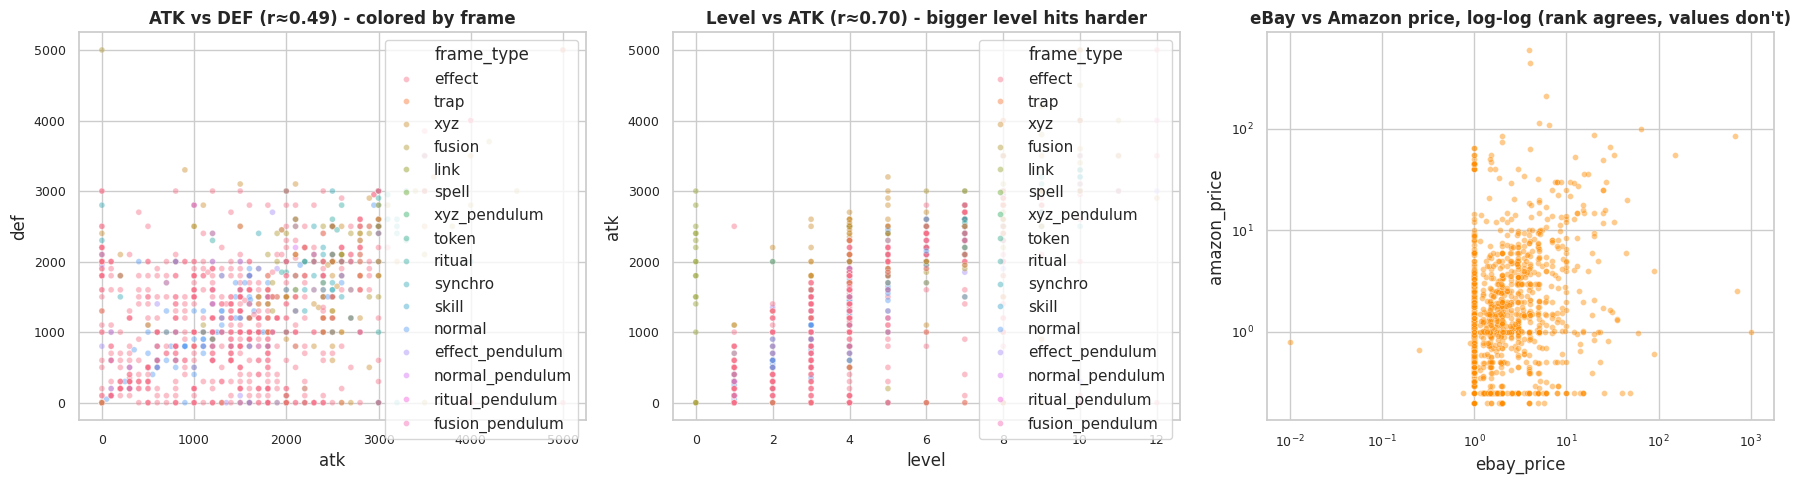

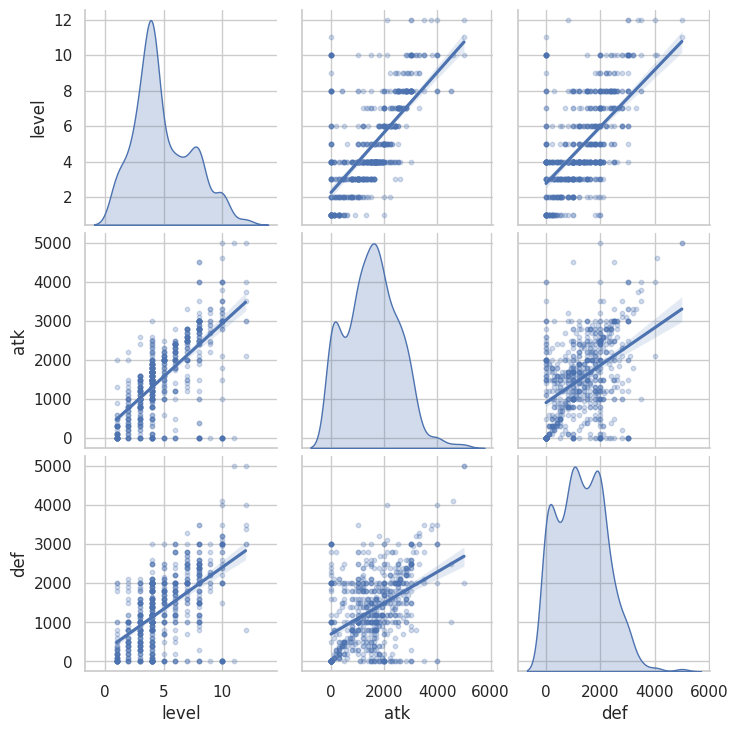

In [14]:
sample = df.sample(min(2000, len(df)), random_state=cfg.SEED)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.scatterplot(data=sample, x="atk", y="def", hue="frame_type", alpha=0.45, s=18, ax=axes[0])
axes[0].set_title("ATK vs DEF (r≈0.49) - colored by frame", fontweight="bold")
sns.scatterplot(data=sample, x="level", y="atk", hue="frame_type", alpha=0.45, s=18, ax=axes[1])
axes[1].set_title("Level vs ATK (r≈0.70) - bigger level hits harder", fontweight="bold")
sns.scatterplot(data=sample, x="ebay_price", y="amazon_price", alpha=0.45, s=18, color="darkorange", ax=axes[2])
axes[2].set_xscale("log"); axes[2].set_yscale("log")
axes[2].set_title("eBay vs Amazon price, log-log (rank agrees, values don't)", fontweight="bold")
for ax in axes: ax.tick_params(labelsize=9)
plt.tight_layout()
plt.savefig(cfg.OUTPUT_DIR / "numeric_scatters.png", dpi=150, bbox_inches="tight")
plt.show()

mon = df[df["atk"].notna() & df["def"].notna() & df["level"].notna()]
sns.pairplot(mon.sample(min(800, len(mon)), random_state=cfg.SEED)[["level", "atk", "def"]],
             kind="reg", diag_kind="kde", plot_kws={"scatter_kws": {"alpha": .25, "s": 10}})
plt.savefig(cfg.OUTPUT_DIR / "numeric_pairplot.png", dpi=150, bbox_inches="tight")
plt.show()


The combat statistics form a tight block, with `level` and `atk` around 0.70, `atk` and `def` around 0.49, and `link_value` and `atk` around 0.68, so stronger monsters sit at higher levels. The prices form a separate and much weaker block: `ebay_price` and `amazon_price` reach a Spearman correlation of 0.62 but a Pearson correlation of only 0.06, because the rank order agrees while the dollar values do not, as a few whale listings break linearity. `set_count`, the number of reprints, is almost orthogonal to everything with an absolute correlation below 0.1, so being reprinted often implies neither strength nor value. Correlations between the combat block and the price block are close to zero, which means flavour and rarity, not stats, drive price.

## Outlier Detection (IQR Rule, Boxen and Price Zoom)

The Tukey IQR fences `[Q1 - 1.5 * IQR, Q3 + 1.5 * IQR]` are computed per column.

Prices are not Gaussian, and for collectibles an outlier is a chase card rather than a dirty record, so the outliers are counted and reported instead of deleted.

In [15]:
def iqr_report(s: pd.Series):
    s = s.dropna()
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    out = ((s < lo) | (s > hi))
    return pd.Series({"n": len(s), "Q1": q1, "Q3": q3, "IQR": iqr,
                      "lo": lo, "hi": hi, "n_out": int(out.sum()),
                      "pct_out": round(100 * out.mean(), 2),
                      "max": s.max(), "min": s.min()})

out_tbl = pd.DataFrame({c: iqr_report(df[c]) for c in num_cols}).T
display(out_tbl.round(2).sort_values("pct_out", ascending=False))
out_tbl.to_csv(cfg.OUTPUT_DIR / "numeric_iqr_outliers.csv")

print("Top-5 by tcgplayer_price:"); display(df.nlargest(5, "tcgplayer_price")[["name", "type", "tcgplayer_price", "set_count"]])
print("Top-5 by ATK:"); display(df.nlargest(5, "atk")[["name", "type", "atk", "def", "level"]])


,n,Q1,Q3,IQR,lo,hi,n_out,pct_out,max,min
cardmarket_price,14533.0,0.06,0.25,0.19,-0.23,0.54,1959.0,13.48,720.91,0.0
amazon_price,14533.0,0.25,1.73,1.48,-1.97,3.95,1925.0,13.25,999.99,0.0
tcgplayer_price,14533.0,0.12,0.33,0.21,-0.20,0.64,1922.0,13.23,1800.00,0.0
ebay_price,14533.0,0.99,2.49,1.50,-1.26,4.74,1757.0,12.09,999.99,0.0
set_count,14533.0,1.00,4.00,3.00,-3.50,8.50,872.0,6.00,78.00,0.0
link_value,473.0,2.00,3.00,1.00,0.50,4.50,17.0,3.59,6.00,1.0
level,8978.0,3.00,6.00,3.00,-1.50,10.50,138.0,1.54,13.00,0.0
atk,9343.0,800.00,2200.00,1400.00,-1300.00,4300.00,39.0,0.42,5000.00,-1.0
def,8870.0,600.00,2000.00,1400.00,-1500.00,4100.00,13.0,0.15,5000.00,-1.0


Top-5 by tcgplayer_price:


,name,type,tcgplayer_price,set_count
id,,,,
30757396,Blood Mefist,Synchro Monster,1800.00,2
10000,Ten Thousand Dragon,Effect Monster,718.19,1
501000006,"Chimaera, the Master of Beasts",Effect Monster,575.00,1
63028558,Anotherverse Solaria,Normal Monster,370.02,0
90844184,Garma Sword,Ritual Monster,367.00,1


Top-5 by ATK:


,name,type,atk,def,level
id,,,,,
37542782,Cyberdark End Dragon,Fusion Monster,5000.0,3800.0,12.0
62873545,Dragon Master Knight,Fusion Monster,5000.0,5000.0,12.0
58931850,Dragon Master Lords,XYZ Monster,5000.0,5000.0,12.0
12381100,Dragon Master Magia,Fusion Monster,5000.0,4000.0,12.0
56863746,Drytron Meteonis DA Draconids,Ritual Effect Monster,5000.0,5000.0,12.0


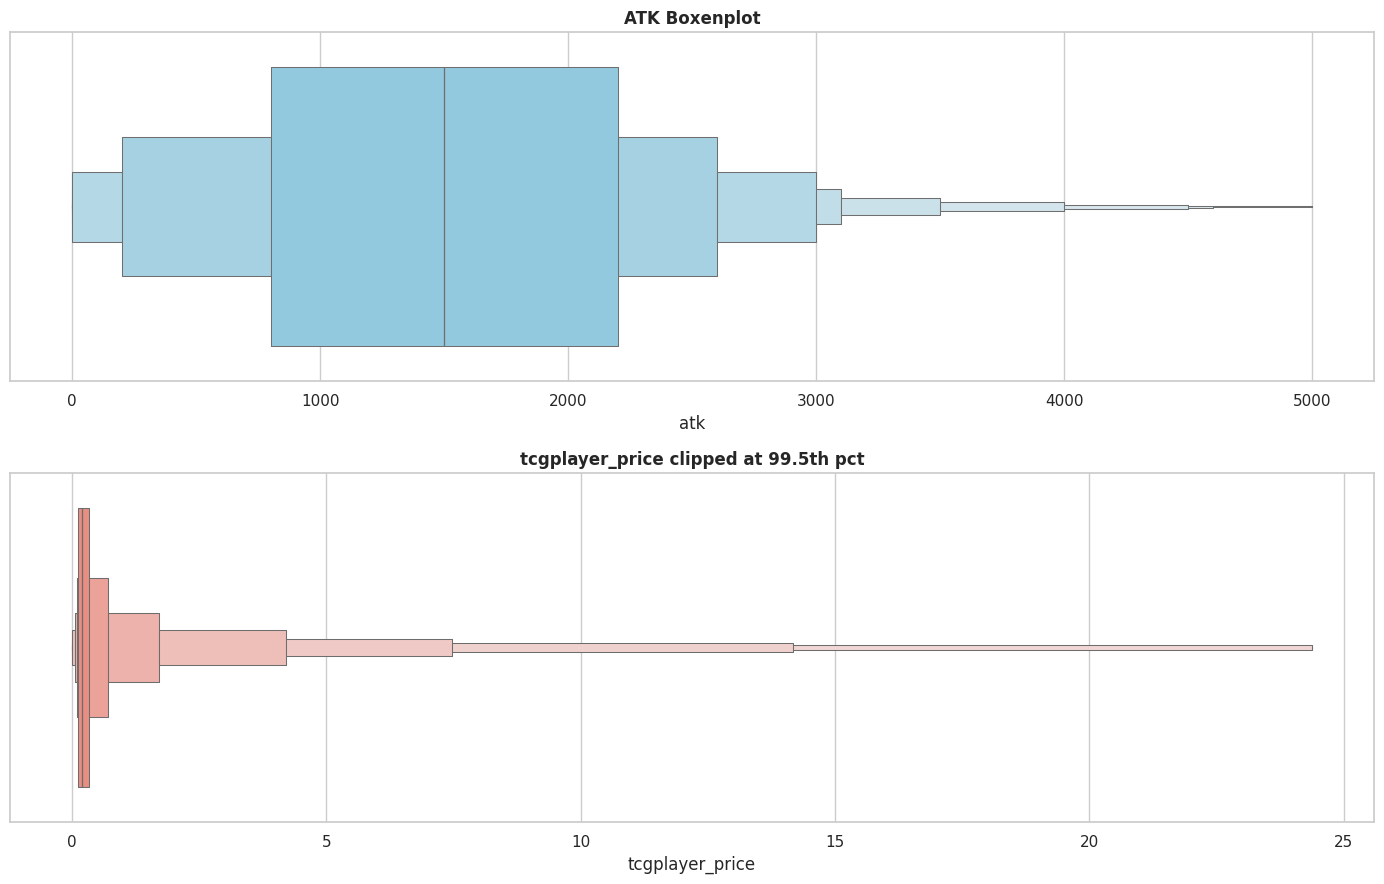

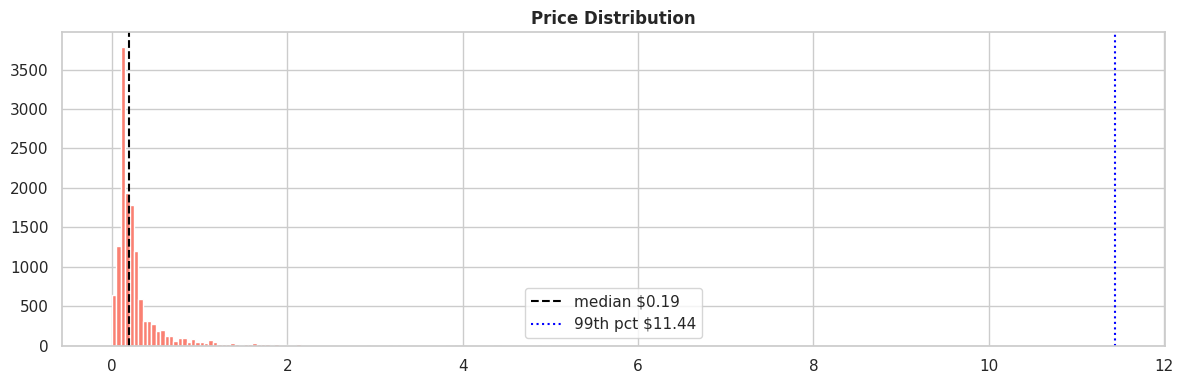

In [16]:
fig, axes = plt.subplots(2, 1, figsize=(14, 9))
sns.boxenplot(x=df["atk"].dropna(), color="skyblue", ax=axes[0])
axes[0].set_title("ATK Boxenplot", fontweight="bold")
sns.boxenplot(x=df["tcgplayer_price"].clip(upper=df["tcgplayer_price"].quantile(0.995)).dropna(),
              color="salmon", ax=axes[1])
axes[1].set_title("tcgplayer_price clipped at 99.5th pct",
                  fontweight="bold")
plt.tight_layout()
plt.savefig(cfg.OUTPUT_DIR / "numeric_outlier_boxen.png", dpi=150, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(12, 4))
s = df["tcgplayer_price"]
ax.hist(s[s <= 5], bins=100, color="salmon", edgecolor="white")
ax.axvline(s.median(), color="black", ls="--", label=f"median ${s.median():.2f}")
ax.axvline(s.quantile(0.99), color="blue", ls=":", label=f"99th pct ${s.quantile(0.99):.2f}")
ax.set_title("Price Distribution",
             fontweight="bold")
ax.legend(); plt.tight_layout()
plt.savefig(cfg.OUTPUT_DIR / "numeric_price_zoom.png", dpi=150, bbox_inches="tight")
plt.show()


Prices flag 12 to 13 percent IQR outliers, which is expected for a market with a $0.19 median and chase cards above $100. The combat outliers are rare and real: 39 cards above 4,300 ATK are boss monsters in the 4,500 to 5,000 range, and 138 cards above level 10.5 are level 11 to 13 gods.

## Categorical Analysis

The object columns are:

- `type` with 29 levels,
- `frame_type` with 17 levels,
- `race` with 86 levels,
- `attribute` with 7 levels plus missing values,
- `archetype` with 659 levels,
- `ban_tcg`, `ban_ocg` and `ban_goat` with 3 levels each and extremely few rows,
- and the free text columns `name`, `description` and `sets`.

,n_unique (incl. NaN),n_unique (excl. NaN),missing %,top value,top share %
archetype,660,659,39.54,NaN,39.5
race,87,86,0.02,Normal,16.6
type,29,29,0.00,Effect Monster,35.3
frame_type,17,17,0.00,effect,41.0
attribute,8,7,35.71,NaN,35.7
ban_tcg,4,3,98.47,NaN,98.5
ban_ocg,4,3,98.67,NaN,98.7
ban_goat,4,3,99.50,NaN,99.5


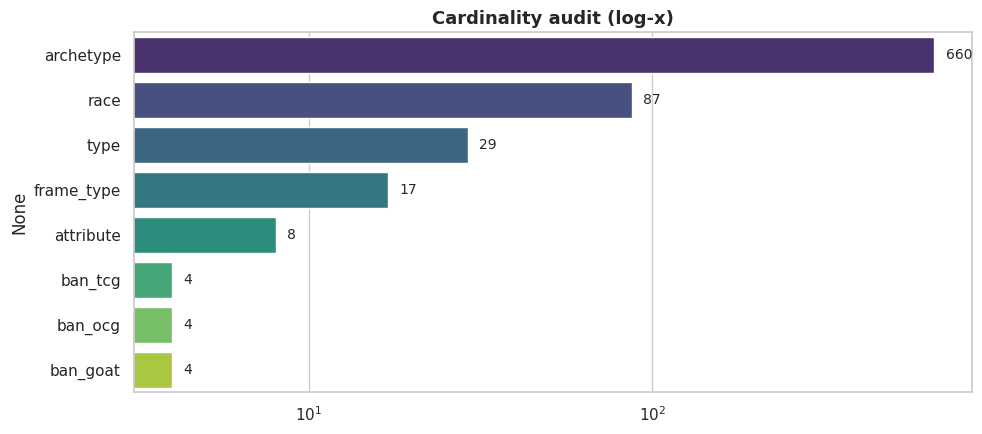

In [17]:
focus_cats = ["type", "frame_type", "race", "attribute", "archetype", "ban_tcg", "ban_ocg", "ban_goat"]
card = pd.DataFrame({
    "n_unique (incl. NaN)": [df[c].nunique(dropna=False) for c in focus_cats],
    "n_unique (excl. NaN)": [df[c].nunique(dropna=True) for c in focus_cats],
    "missing %": (df[focus_cats].isna().mean() * 100).round(2),
    "top value": [df[c].value_counts(dropna=False).index[0] for c in focus_cats],
    "top share %": [(df[c].value_counts(dropna=False, normalize=True).iloc[0] * 100).round(1) for c in focus_cats],
}).sort_values("n_unique (incl. NaN)", ascending=False)
display(card)
card.to_csv(cfg.OUTPUT_DIR / "categorical_cardinality.csv")

fig, ax = plt.subplots(figsize=(10, 4.5))
sns.barplot(x=card["n_unique (incl. NaN)"].values, y=card.index, hue=card.index,
            palette="viridis", legend=False, ax=ax)
ax.set_xscale("log")
for i, v in enumerate(card["n_unique (incl. NaN)"].values):
    ax.text(v * 1.08, i, str(v), va="center", fontsize=10)
ax.set_title("Cardinality audit (log-x)", fontweight="bold", fontsize=13)
plt.tight_layout(); plt.savefig(cfg.OUTPUT_DIR / "categorical_cardinality.png", dpi=150, bbox_inches="tight")
plt.show()


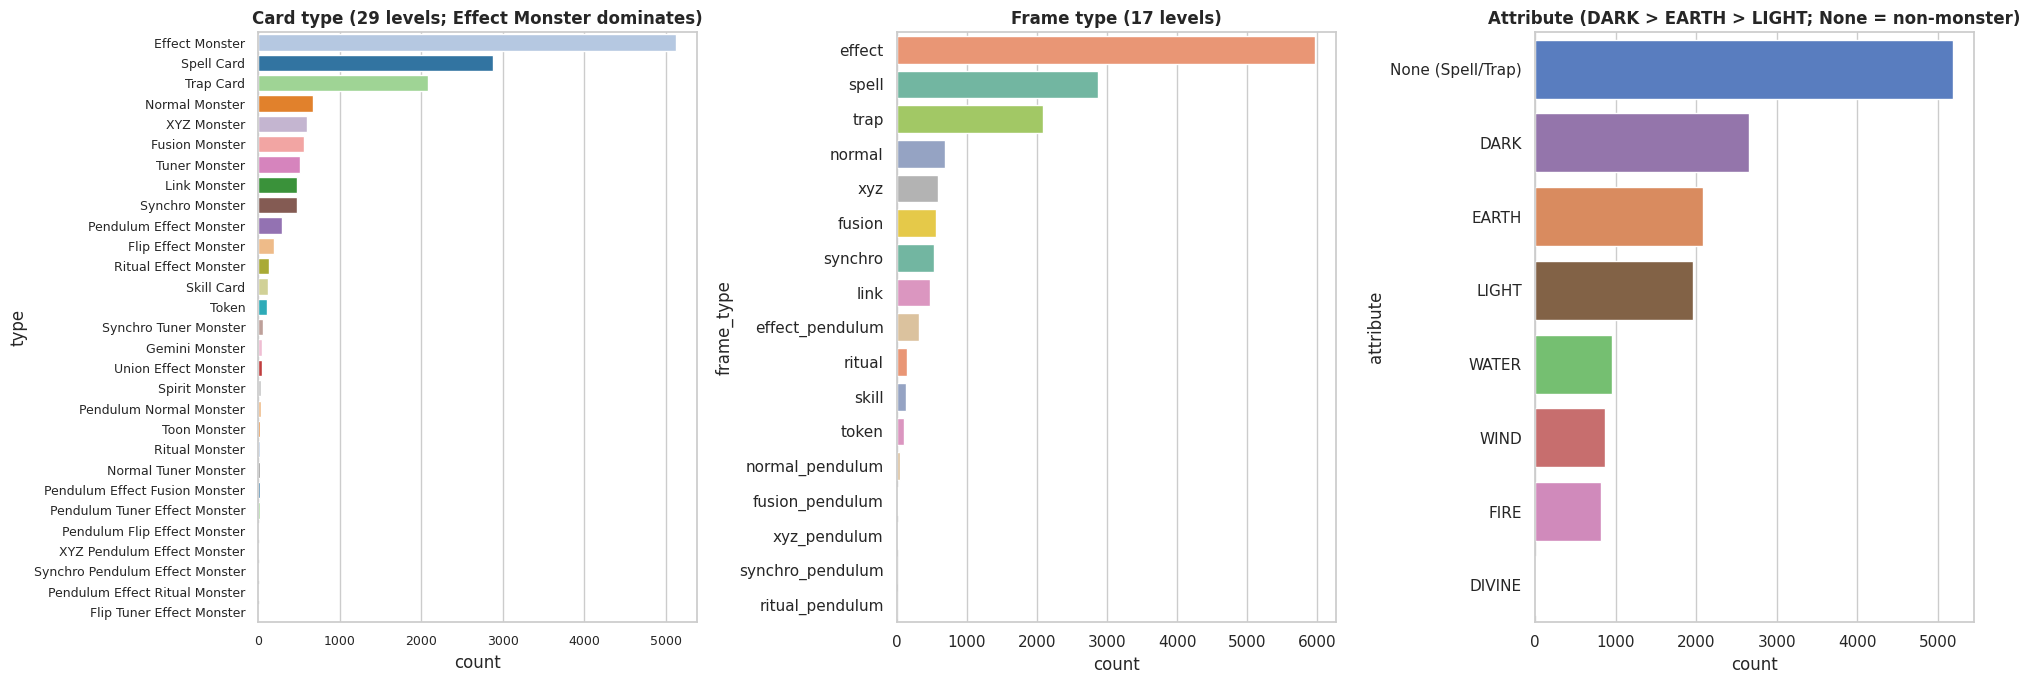

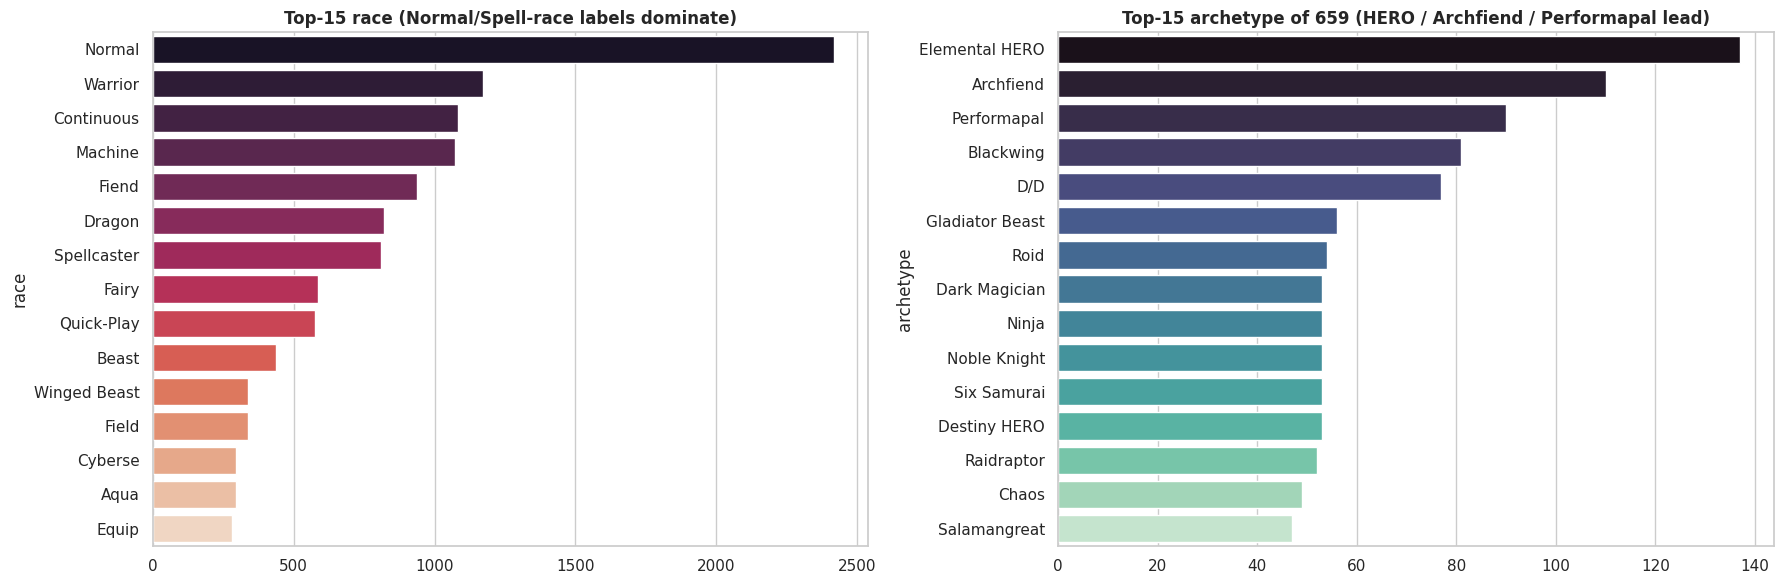

Archetype coverage: top-15 = 1018 cards (7.0%), NaN (no archetype) = 5747 (39.5%)


In [18]:
type_order = df["type"].value_counts().index
frame_order_all = df["frame_type"].value_counts().index
attribute_filled = df["attribute"].fillna("None (Spell/Trap)")

fig, axes = plt.subplots(1, 3, figsize=(20, 7))
sns.countplot(y=df["type"], order=type_order, hue=df["type"], palette="tab20", legend=False, ax=axes[0])
axes[0].set_title("Card type (29 levels; Effect Monster dominates)", fontweight="bold")
axes[0].tick_params(labelsize=9)
sns.countplot(y=df["frame_type"], order=frame_order_all, hue=df["frame_type"], palette="Set2", legend=False, ax=axes[1])
axes[1].set_title("Frame type (17 levels)", fontweight="bold")
sns.countplot(y=attribute_filled, order=attribute_filled.value_counts().index,
              hue=attribute_filled, palette="muted", legend=False, ax=axes[2])
axes[2].set_title("Attribute (DARK > EARTH > LIGHT; None = non-monster)", fontweight="bold")
plt.tight_layout(); plt.savefig(cfg.OUTPUT_DIR / "categorical_core.png", dpi=150, bbox_inches="tight")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
top_race = df["race"].value_counts().head(15)
sns.barplot(x=top_race.values, y=top_race.index, hue=top_race.index, palette="rocket", legend=False, ax=axes[0])
axes[0].set_title("Top-15 race (Normal/Spell-race labels dominate)", fontweight="bold")
top_arch = df["archetype"].value_counts().head(15)
sns.barplot(x=top_arch.values, y=top_arch.index, hue=top_arch.index, palette="mako", legend=False, ax=axes[1])
axes[1].set_title("Top-15 archetype of 659 (HERO / Archfiend / Performapal lead)", fontweight="bold")
plt.tight_layout(); plt.savefig(cfg.OUTPUT_DIR / "categorical_race_archetype.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Archetype coverage: top-15 = {top_arch.sum()} cards ({top_arch.sum()/len(df)*100:.1f}%), "
      f"NaN (no archetype) = {df['archetype'].isna().sum()} ({df['archetype'].isna().mean()*100:.1f}%)")

The most frequent archetypes are the ones used by the main character decks in Yu-Gi-Oh! GX and Yu-Gi-Oh! Zexal, especially Elemental HERO and Performapal.

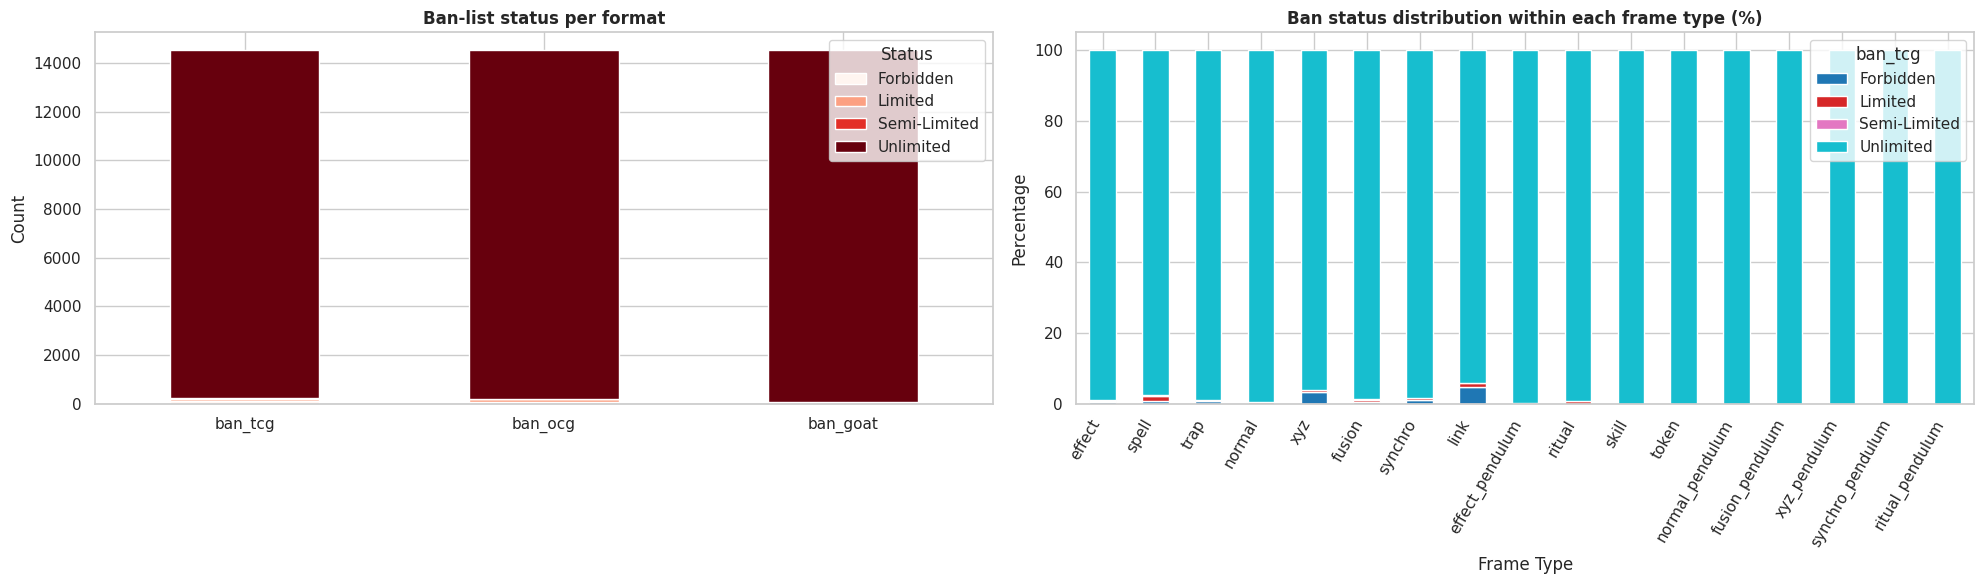

ban_tcg,Forbidden,Limited,Semi-Limited,Unlimited
frame_type,,,,
effect,32,21,5,5907
spell,20,44,4,2810
trap,15,8,0,2058
normal,0,4,0,681
xyz,19,4,0,568
fusion,3,3,1,557
synchro,6,3,0,520
link,22,6,0,445
effect_pendulum,0,1,0,313


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(20, 6))

ban_cols = ["ban_tcg", "ban_ocg", "ban_goat"]

ban = (
    pd.DataFrame({
        c: df[c].fillna("Unlimited").value_counts()
        for c in ban_cols
    }).fillna(0)
)

ban = ban.reindex(["Forbidden", "Limited", "Semi-Limited", "Unlimited"], fill_value=0)

ban.T.plot(kind="bar",stacked=True,ax=axes[0],colormap="Reds",edgecolor="white",)

axes[0].set_title("Ban-list status per format",fontweight="bold")
axes[0].set_xlabel("")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=0)
axes[0].legend(title="Status")


ct = pd.crosstab(df["frame_type"].fillna("Unknown"),df["ban_tcg"].fillna("Unlimited"),normalize="index") * 100
ct = ct.reindex(columns=["Forbidden", "Limited", "Semi-Limited", "Unlimited"],fill_value=0)

frame_order = (df["frame_type"].fillna("Unknown").value_counts().index)
ct = ct.loc[frame_order]


ct.plot(kind="bar",stacked=True,ax=axes[1],colormap="tab10",edgecolor="white")

axes[1].set_title("Ban status distribution within each frame type (%)",fontweight="bold")
axes[1].set_xlabel("Frame Type")
axes[1].set_ylabel("Percentage")
plt.setp(axes[1].get_xticklabels(),rotation=60,ha="right")
axes[1].legend(title="ban_tcg")

plt.tight_layout()
plt.savefig(cfg.OUTPUT_DIR / "categorical_bans.png",dpi=150,bbox_inches="tight")
plt.show()

display(
    pd.crosstab(
        df["frame_type"].fillna("Unknown"),
        df["ban_tcg"].fillna("Unlimited")
    )
    .sort_values("Unlimited", ascending=False)
)

The low cardinality game axes `type`, `frame_type` and `attribute` can be plotted in full, while `race` with 86 levels and `archetype` with 659 levels and 40 percent missing need a Top-N treatment, and for modelling a target or frequency encoding instead of a raw one-hot. Bans are events below 2 percent frequency, so they are handled as flags, and the missing `None` attribute is structural for spell and trap cards rather than missing at random.

## Card Name Keywords and Word Cloud

Card names carry the design language of the game, with words such as "Dragon", "Dark", "Number" and "HERO". The names are tokenized with a letters-only regex, one-letter tokens are dropped and the remaining tokens are counted.

,word,count
0,dragon,804
1,dark,295
2,knight,247
3,beast,218
4,hero,187
5,king,184
6,number,164
7,eyes,154
8,world,147
9,warrior,131


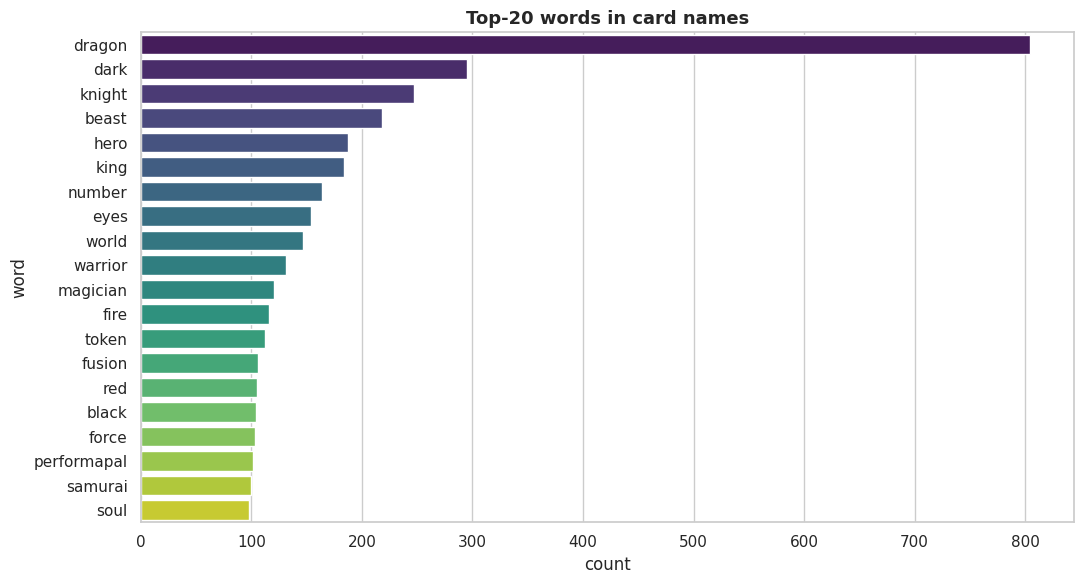

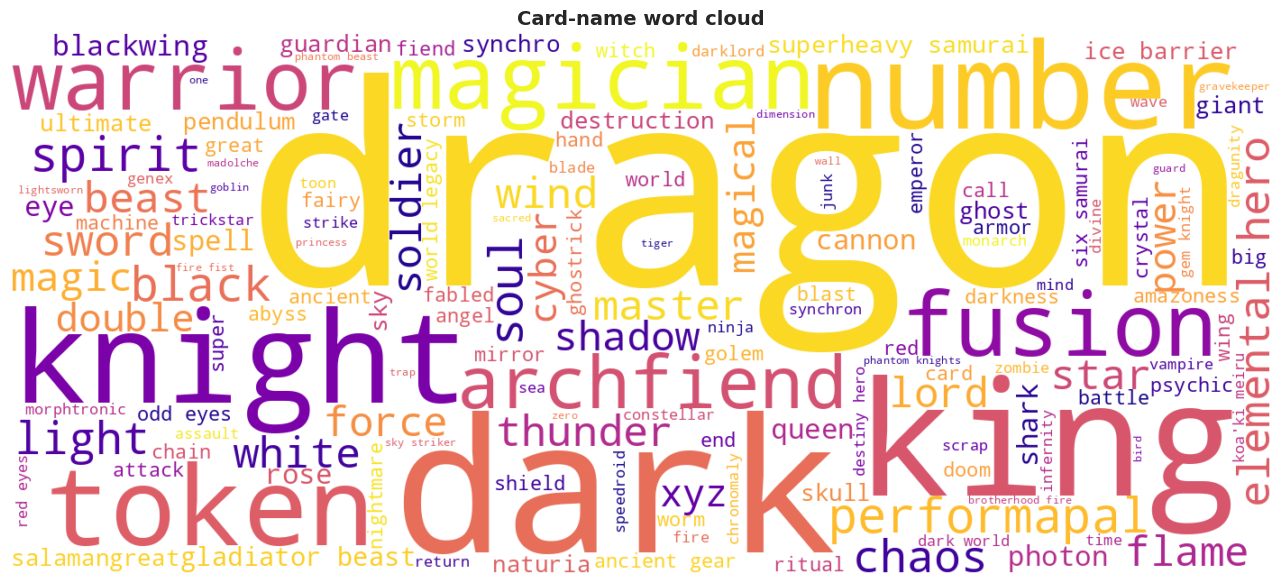

In [20]:


stop_extra = {"the", "of", "a", "an", "and", "in", "on", "to", "for", "with"}
name_tokens = []
for n in df["name"].fillna(""):
    toks = re.findall(r"[A-Za-z']+", n.lower())
    name_tokens.extend([t.strip("'") for t in toks if len(t.strip("'")) > 1 and t not in stop_extra])

cnt = Counter(name_tokens)
top_name = pd.DataFrame(cnt.most_common(25), columns=["word", "count"])
display(top_name)
top_name.to_csv(cfg.OUTPUT_DIR / "name_top_words.csv", index=False)

fig, ax = plt.subplots(figsize=(11, 6))
sns.barplot(data=top_name.head(20), x="count", y="word", hue="word", palette="viridis", legend=False, ax=ax)
ax.set_title("Top-20 words in card names", fontweight="bold", fontsize=13)
plt.tight_layout(); plt.savefig(cfg.OUTPUT_DIR / "name_top_words.png", dpi=150, bbox_inches="tight")
plt.show()

wc = WordCloud(width=1400, height=600, background_color="white", colormap="plasma",
                max_words=150).generate(" ".join(name_tokens))
fig, ax = plt.subplots(figsize=(14, 6))
ax.imshow(wc, interpolation="bilinear")
ax.axis("off")
ax.set_title("Card-name word cloud", fontweight="bold", fontsize=14)
plt.tight_layout(); plt.savefig(cfg.OUTPUT_DIR / "name_wordcloud.png", dpi=150, bbox_inches="tight")
plt.show()


## Text and Description NLP Testing

`description` holds the actual card rules text and is almost unique, with 14,483 unique values out of 14,533 rows. The pipeline is: (a) length features in characters and words, overall and per card type, (b) a bag of words model with unigrams and bigrams through the sklearn `CountVectorizer`, (c) TF-IDF top terms split into Monster, Spell and Trap, and (d) a word cloud with an SVD semantic map. No download is needed because the sklearn English stop words are used.

,desc_chars,desc_words
count,14533.0,14533.0
mean,313.5,56.0
std,163.2,29.4
min,2.0,1.0
25%,169.0,30.0
50%,313.0,56.0
75%,448.0,80.0
max,1006.0,188.0


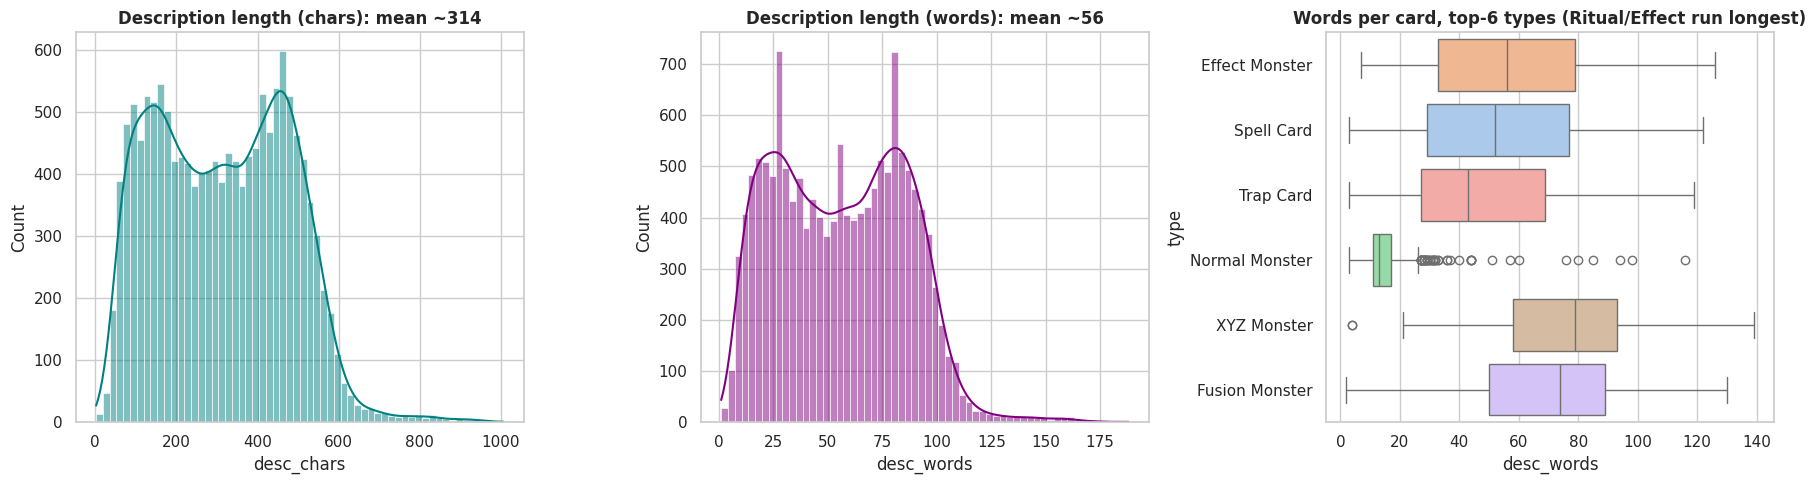

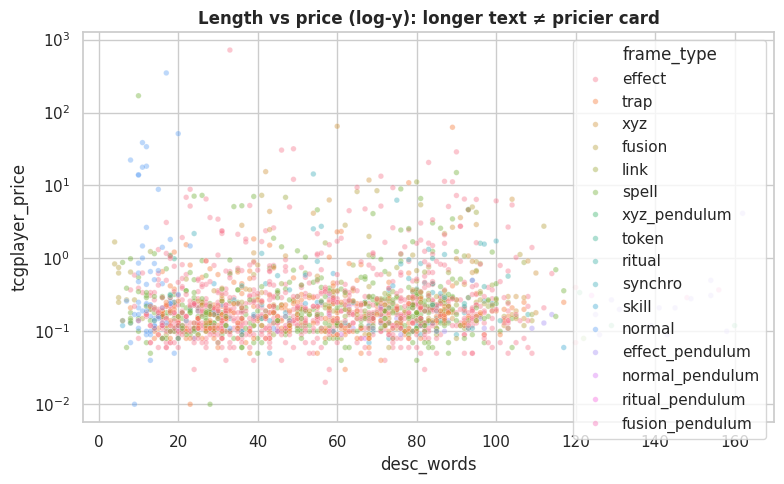

In [21]:
df["desc_chars"] = df["description"].fillna("").str.len()
df["desc_words"] = df["description"].fillna("").str.split().str.len()
display(df[["desc_chars", "desc_words"]].describe().round(1))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.histplot(df["desc_chars"], bins=60, kde=True, color="teal", ax=axes[0])
axes[0].set_title("Description length (chars): mean ~314", fontweight="bold")
sns.histplot(df["desc_words"], bins=60, kde=True, color="purple", ax=axes[1])
axes[1].set_title("Description length (words): mean ~56", fontweight="bold")
top_types = df["type"].value_counts().head(6).index
sns.boxplot(data=df[df["type"].isin(top_types)], x="desc_words", y="type",
            order=df.loc[df["type"].isin(top_types), "type"].value_counts().index,
            palette="pastel", hue="type", legend=False, ax=axes[2])
axes[2].set_title("Words per card, top-6 types (Ritual/Effect run longest)", fontweight="bold")
plt.tight_layout(); plt.savefig(cfg.OUTPUT_DIR / "nlp_lengths.png", dpi=150, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(data=df.sample(2000, random_state=cfg.SEED), x="desc_words",
                y="tcgplayer_price", hue="frame_type", alpha=0.4, s=16, ax=ax)
ax.set_yscale("log")
ax.set_title("Length vs price (log-y): longer text ≠ pricier card", fontweight="bold")
plt.tight_layout(); plt.savefig(cfg.OUTPUT_DIR / "nlp_length_vs_price.png", dpi=150, bbox_inches="tight")
plt.show()


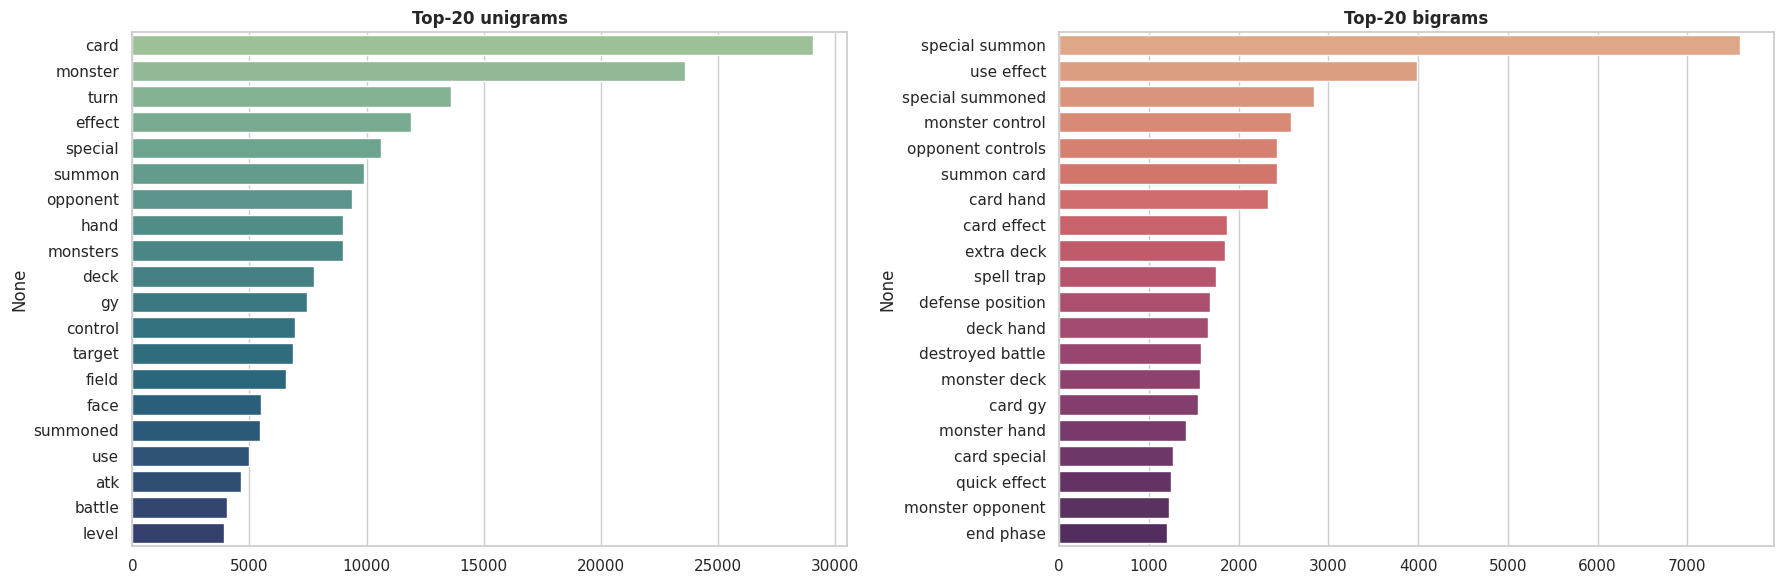

Unigrams: {'card': 29070, 'monster': 23598, 'turn': 13613, 'effect': 11917, 'special': 10615, 'summon': 9879, 'opponent': 9375, 'hand': 9008, 'monsters': 8998, 'deck': 7764}
Bigrams: {'special summon': 7588, 'use effect': 3989, 'special summoned': 2840, 'monster control': 2583, 'opponent controls': 2431, 'summon card': 2422, 'card hand': 2322, 'card effect': 1873, 'extra deck': 1843, 'spell trap': 1746}


In [22]:

texts = df["description"].fillna("")
uni = CountVectorizer(stop_words="english", max_features=25, min_df=5)
Xu = uni.fit_transform(texts)
freq_u = pd.Series(np.asarray(Xu.sum(axis=0)).ravel(), index=uni.get_feature_names_out()
                   ).sort_values(ascending=False)

bi = CountVectorizer(stop_words="english", ngram_range=(2, 2), max_features=25, min_df=5)
Xb = bi.fit_transform(texts)
freq_b = pd.Series(np.asarray(Xb.sum(axis=0)).ravel(), index=bi.get_feature_names_out()
                   ).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
sns.barplot(x=freq_u.head(20).values, y=freq_u.head(20).index, hue=freq_u.head(20).index,
            palette="crest", legend=False, ax=axes[0])
axes[0].set_title("Top-20 unigrams", fontweight="bold")
sns.barplot(x=freq_b.head(20).values, y=freq_b.head(20).index, hue=freq_b.head(20).index,
            palette="flare", legend=False, ax=axes[1])
axes[1].set_title("Top-20 bigrams", fontweight="bold")
plt.tight_layout(); plt.savefig(cfg.OUTPUT_DIR / "nlp_bow.png", dpi=150, bbox_inches="tight")
plt.show()
print("Unigrams:", freq_u.head(10).to_dict())
print("Bigrams:", freq_b.head(10).to_dict())


,Monster,Spell,Trap
card,0.1249,0.0915,0.1129
control,NaN,NaN,0.0620
deck,NaN,0.0607,NaN
effect,0.0591,NaN,0.0615
field,NaN,NaN,0.0579
gy,NaN,0.0542,0.0555
hand,0.0536,0.0593,NaN
monster,0.0923,0.1125,0.1261
monsters,0.0534,0.0617,0.0616
opponent,0.0574,0.0535,0.0780


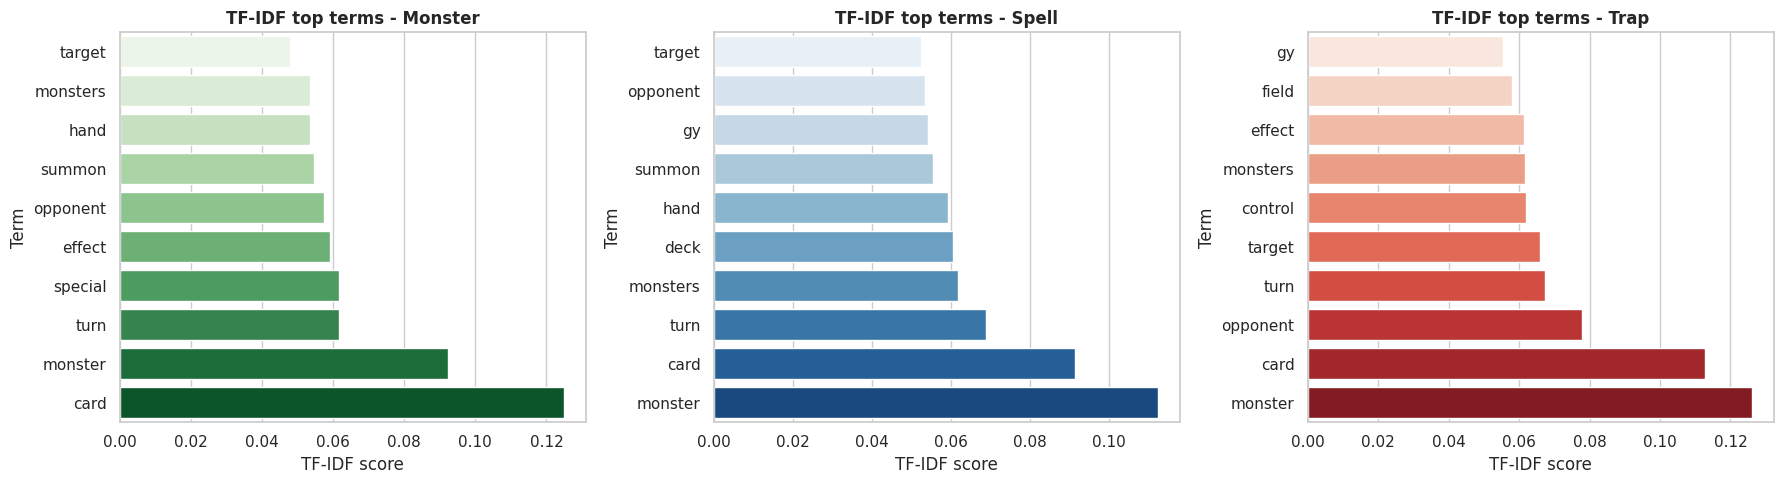

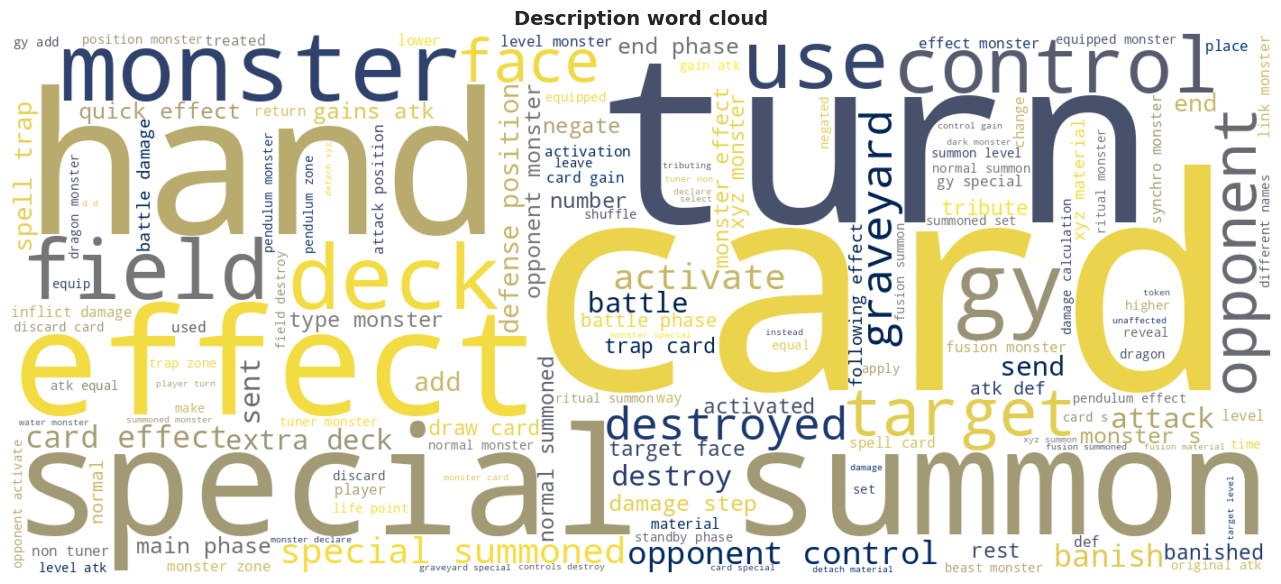

In [23]:

def top_tfidf(sub: pd.Series, k=10):
    v = TfidfVectorizer(stop_words="english", max_features=3000, min_df=5)
    X = v.fit_transform(sub.fillna(""))
    scores = np.asarray(X.mean(axis=0)).ravel()
    return pd.Series(scores, index=v.get_feature_names_out()).sort_values(ascending=False).head(k)

is_mon = df["frame_type"].isin(["effect", "normal", "fusion", "synchro", "xyz", "link"])
is_spell = df["frame_type"] == "spell"
is_trap = df["frame_type"] == "trap"
terms = pd.DataFrame({
    "Monster": top_tfidf(df.loc[is_mon, "description"]),
    "Spell": top_tfidf(df.loc[is_spell, "description"]),
    "Trap": top_tfidf(df.loc[is_trap, "description"]),
})
display(terms.round(4))
terms.to_csv(cfg.OUTPUT_DIR / "nlp_tfidf_by_family.csv")

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=False)
for ax, col, color in zip(axes, ["Monster", "Spell", "Trap"], ["Greens", "Blues", "Reds"]):
    s = terms[col].dropna().sort_values()
    sns.barplot(x=s.values, y=s.index, hue=s.index, palette=color, legend=False, ax=ax)
    ax.set_xlabel("TF-IDF score")
    ax.set_ylabel("Term")
    ax.set_title(f"TF-IDF top terms - {col}", fontweight="bold")
plt.tight_layout(); plt.savefig(cfg.OUTPUT_DIR / "nlp_tfidf.png", dpi=150, bbox_inches="tight")
plt.show()

desc_wc = WordCloud(width=1400, height=600, background_color="white", colormap="cividis",
                    max_words=150, stopwords=set(uni.get_stop_words()) if hasattr(uni, "get_stop_words") else None
                    ).generate(" ".join(df["description"].fillna("").str.lower()))
fig, ax = plt.subplots(figsize=(14, 6))
ax.imshow(desc_wc, interpolation="bilinear"); ax.axis("off")
ax.set_title("Description word cloud", fontweight="bold", fontsize=14)
plt.tight_layout(); plt.savefig(cfg.OUTPUT_DIR / "nlp_wordcloud.png", dpi=150, bbox_inches="tight")
plt.show()


The description vocabulary is dominated by in-game terms such as `turn`, `card` and `hand`. Each card family also has its own vocabulary, which the TF-IDF contrast shows.

# Data Preprocessing

The exploratory part above works on the raw values on purpose, so that every data problem stays visible. This section turns the raw frame into a clean, modelling-ready frame and records each decision instead of hiding it.

## Problems Found in the Raw Data

The raw profile, the missing value heatmap and the numeric summary expose nine problems that would distort any later model.

| # | Problem | Evidence | Action |
|---|---------|----------|--------|
| 1 | `rank` is empty in every row | 0 non-null values in `df.info()` | dropped with the two image columns |
| 2 | a price of `0.0` means no listing, not a free card | 504 to 2,581 rows per marketplace | converted to missing values |
| 3 | an attack or defence of `-1` means the value is not printed | 84 and 55 rows | converted to missing values |
| 4 | a level of `0` means the monster has no level | 115 rows, mostly Link monsters | converted to missing values |
| 5 | the card id is used as a text index | `df.index = df["id"]` | restored as an integer `card_id` key |
| 6 | `sets` stores a Python list as plain text | values start with `[{` | parsed into a set level table |
| 7 | `attribute` is empty for every non-monster | 5,190 rows | filled with `None` and flagged by `is_monster` |
| 8 | `archetype` has 659 levels and 39.5 percent missing | cardinality audit | Top-15 grouping plus frequency encoding |
| 9 | the ban list columns are 98.5 to 99.5 percent missing | 73 to 222 non-null rows | filled with `Unlimited` and turned into severity and flags |

In [24]:
price_cols = ["tcgplayer_price", "cardmarket_price", "ebay_price", "amazon_price"]
stat_cols = ["level", "link_value", "atk", "def"]
ban_cols = ["ban_tcg", "ban_ocg", "ban_goat"]
monster_frames = ["effect", "effect_pendulum", "normal", "normal_pendulum", "fusion", "fusion_pendulum",
                  "ritual", "ritual_pendulum", "synchro", "synchro_pendulum", "xyz", "xyz_pendulum", "link"]
text_cols = ["name", "type", "frame_type", "description", "race", "attribute", "archetype",
            "ban_tcg", "ban_ocg", "ban_goat", "sets"]
release_fields = ["set_name", "set_code", "set_rarity", "set_rarity_code", "set_price"]

numeric_audit = pd.DataFrame({
    "dtype": df[stat_cols + price_cols + ["set_count"]].dtypes,
    "missing %": (df[stat_cols + price_cols + ["set_count"]].isna().mean() * 100).round(2),
    "n_unique": df[stat_cols + price_cols + ["set_count"]].nunique(),
    "min": df[stat_cols + price_cols + ["set_count"]].min(),
    "max": df[stat_cols + price_cols + ["set_count"]].max(),
    "n_zero": (df[stat_cols + price_cols + ["set_count"]] == 0).sum(),
    "n_minus_one": (df[stat_cols + price_cols + ["set_count"]] == -1).sum(),
})
display(numeric_audit)

text_audit = pd.DataFrame({
    "dtype": df[text_cols].dtypes,
    "missing %": (df[text_cols].isna().mean() * 100).round(2),
    "n_unique": df[text_cols].nunique(),
})
display(text_audit)

parsed_sets = df["sets"].map(ast.literal_eval)
structure_audit = pd.Series({
    "rows": len(df),
    "duplicate card id": int(df.index.duplicated().sum()),
    "duplicate card name": int(df["name"].duplicated().sum()),
    "sets parsed as a list": int(parsed_sets.map(lambda records: isinstance(records, list)).sum()),
    "set_count matches the parsed length": int((parsed_sets.map(len) == df["set_count"]).sum()),
    "cards with no release": int((df["set_count"] == 0).sum()),
    "release rows after exploding": int(parsed_sets.map(len).sum()),
    "names with a quotation mark": int(df["name"].str.contains('"', regex=False).sum()),
    "descriptions with padding": int((df["description"] != df["description"].str.strip()).sum()),
    "descriptions with a new line": int(df["description"].str.contains(r"\n", regex=True).sum()),
})
display(structure_audit.to_frame("count"))

,dtype,missing %,n_unique,min,max,n_zero,n_minus_one
level,float64,38.22,14,0.0,13.00,115,0
link_value,float64,96.75,6,1.0,6.00,0,0
atk,float64,35.71,83,-1.0,5000.00,722,84
def,float64,38.97,76,-1.0,5000.00,908,55
tcgplayer_price,float64,0.00,751,0.0,1800.00,530,0
cardmarket_price,float64,0.00,699,0.0,720.91,504,0
ebay_price,float64,0.00,697,0.0,999.99,2290,0
amazon_price,float64,0.00,1084,0.0,999.99,2581,0
set_count,int64,0.00,50,0.0,78.00,519,0


,dtype,missing %,n_unique
name,object,0.00,14533
type,object,0.00,29
frame_type,object,0.00,17
description,object,0.00,14483
race,object,0.02,86
attribute,object,35.71,7
archetype,object,39.54,659
ban_tcg,object,98.47,3
ban_ocg,object,98.67,3
ban_goat,object,99.50,3


,count
rows,14533
duplicate card id,0
duplicate card name,0
sets parsed as a list,14533
set_count matches the parsed length,14533
cards with no release,519
release rows after exploding,44517
names with a quotation mark,83
descriptions with padding,13
descriptions with a new line,3601


## Fix Keys, Whitespace and Data Types

The raw frame carries the card id as a text index, which makes joins and `.loc` slicing awkward, and the numeric columns are floats even where a missing value should stay an integer. The key becomes a plain integer column, every text column is trimmed, and the combat statistics use the nullable `Int64` type so a spell card stays empty instead of turning into a fake number.

In [25]:
df_clean = df.reset_index()
df_clean.index = pd.RangeIndex(len(df_clean))
df_clean = df_clean.rename(columns={"id": "card_id"})
df_clean["card_id"] = df_clean["card_id"].astype("int64")
dtypes_before = df.dtypes.astype(str)

trimmed = {}
for col in df_clean.select_dtypes(include="object").columns:
    trimmed[col] = int((df_clean[col].notna() & df_clean[col].ne(df_clean[col].str.strip())).sum())
    df_clean[col] = df_clean[col].str.strip()

df_clean[stat_cols] = df_clean[stat_cols].astype("Int64")
df_clean["set_count"] = df_clean["set_count"].astype("int64")
df_clean[price_cols] = df_clean[price_cols].astype("float64").round(2)
dtypes_after = df_clean.dtypes.astype(str)

print("cells trimmed per text column:", {col: count for col, count in trimmed.items() if count})
display(pd.DataFrame({"before": dtypes_before, "after": dtypes_after.reindex(dtypes_before.index)}))
df_clean.head(3)

cells trimmed per text column: {'description': 13}


,before,after
name,object,object
type,object,object
frame_type,object,object
description,object,object
race,object,object
attribute,object,object
archetype,object,object
level,float64,Int64
link_value,float64,Int64
atk,float64,Int64


,card_id,name,type,frame_type,description,race,attribute,archetype,level,link_value,...,cardmarket_price,ebay_price,amazon_price,ban_tcg,ban_ocg,ban_goat,set_count,sets,desc_chars,desc_words
0,80181649,"""A Case for K9""",Spell Card,spell,"When this card is activated: You can add 1 ""K9...",Continuous,NaN,K9,<NA>,<NA>,...,0.23,0.00,0.00,Limited,NaN,NaN,4,"[{'set_name': 'Justice Hunters', 'set_code': '...",454,92
1,34541863,"""A"" Cell Breeding Device",Spell Card,spell,"During each of your Standby Phases, put 1 A-Co...",Continuous,NaN,Alien,<NA>,<NA>,...,0.10,0.99,24.45,NaN,NaN,NaN,1,"[{'set_name': 'Force of the Breaker', 'set_cod...",96,16
2,64163367,"""A"" Cell Incubator",Spell Card,spell,Each time an A-Counter(s) is removed from play...,Continuous,NaN,Alien,<NA>,<NA>,...,0.12,1.25,0.50,NaN,NaN,NaN,1,"[{'set_name': ""Gladiator's Assault"", 'set_code...",188,32


## Convert Sentinel Values into Real Missing Values

The database behind the dataset uses placeholders instead of empty cells. A price of `0.0` means the card has no listing on that marketplace, an attack or defence of `-1` means the value is not printed on the physical card, and a level of `0` marks a monster that has no level, such as a Link monster. Counting these as real numbers drags every mean, correlation and histogram towards zero, so they become missing values here. A real attack of `0` is kept, because Yu-Gi-Oh! monsters can genuinely have zero attack.

In [26]:
sentinels = {
    "tcgplayer_price": (0, "no listing on TCGplayer"),
    "cardmarket_price": (0, "no listing on Cardmarket"),
    "ebay_price": (0, "no listing on eBay"),
    "amazon_price": (0, "no listing on Amazon"),
    "level": (0, "monster without a level, Link monsters for example"),
    "atk": (-1, "attack value not printed on the card"),
    "def": (-1, "defence value not printed on the card"),
}

sentinel_rows = []
for col, (placeholder, meaning) in sentinels.items():
    converted = int((df_clean[col] == placeholder).sum())
    df_clean[col] = df_clean[col].where(df_clean[col] != placeholder)
    sentinel_rows.append({"column": col, "placeholder": placeholder, "meaning": meaning, "rows converted": converted})

sentinel_report = pd.DataFrame(sentinel_rows)
display(sentinel_report)
sentinel_report.to_csv(cfg.OUTPUT_DIR / "preprocessing_sentinels.csv", index=False)

,column,placeholder,meaning,rows converted
0,tcgplayer_price,0,no listing on TCGplayer,530
1,cardmarket_price,0,no listing on Cardmarket,504
2,ebay_price,0,no listing on eBay,2290
3,amazon_price,0,no listing on Amazon,2581
4,level,0,"monster without a level, Link monsters for exa...",115
5,atk,-1,attack value not printed on the card,84
6,def,-1,defence value not printed on the card,55


## Mark Structural Missing Values

The missing values in `level`, `atk`, `def` and `attribute` are structural, not random: a spell card has no attack by design of the game. Filling them would invent data, so the frame keeps them missing and records the reason instead. `is_monster` and `card_kind` describe the card family, `is_pendulum` marks pendulum monsters, and `attribute` becomes a complete category with `None` for the 5,189 non-monster cards.

In [27]:
df_clean["is_monster"] = df_clean["frame_type"].isin(monster_frames)
df_clean["card_kind"] = np.select(
    [df_clean["is_monster"], df_clean["frame_type"].eq("spell"), df_clean["frame_type"].eq("trap"),
     df_clean["frame_type"].eq("skill"), df_clean["frame_type"].eq("token")],
    ["Monster", "Spell", "Trap", "Skill", "Token"],
    default="Other")
df_clean["is_pendulum"] = df_clean["frame_type"].str.endswith("pendulum")
df_clean["attribute"] = df_clean["attribute"].fillna("None")

non_monster = ~df_clean["is_monster"]
structure_check = pd.Series({
    "cards": len(df_clean),
    "monster cards": int(df_clean["is_monster"].sum()),
    "non-monster cards": int(non_monster.sum()),
    "non-monster with a level": int((non_monster & df_clean["level"].notna()).sum()),
    "non-monster with an attack": int((non_monster & df_clean["atk"].notna()).sum()),
    "non-monster with a link value": int((non_monster & df_clean["link_value"].notna()).sum()),
    "monster without an attribute": int((df_clean["is_monster"] & df_clean["attribute"].eq("None")).sum()),
    "monster without a level": int((df_clean["is_monster"] & df_clean["level"].isna()).sum()),
    "monster without an attack": int((df_clean["is_monster"] & df_clean["atk"].isna()).sum()),
})
display(structure_check.to_frame("rows"))
display(df_clean["card_kind"].value_counts().to_frame("cards"))

,rows
cards,14533
monster cards,9344
non-monster cards,5189
non-monster with a level,0
non-monster with an attack,0
non-monster with a link value,0
monster without an attribute,1
monster without a level,481
monster without an attack,85


,cards
card_kind,
Monster,9344
Spell,2878
Trap,2081
Skill,124
Token,106


## Clean the Text Columns

Card names keep decorative quotation marks such as `"A" Cell Breeding Device`, and 3,601 descriptions still contain the line breaks of the scraped page. Both are normalised so the token counts, the n-grams and the word clouds are not distorted by punctuation and layout.

In [28]:
text_before = pd.Series({
    "names with a quotation mark": int(df_clean["name"].str.contains('"', regex=False).sum()),
    "descriptions with a new line": int(df_clean["description"].str.contains(r"\n", regex=True).sum()),
    "characters in all names": int(df_clean["name"].str.len().sum()),
    "characters in all descriptions": int(df_clean["description"].str.len().sum()),
})

df_clean["name"] = df_clean["name"].str.replace('"', "", regex=False)
df_clean["name"] = df_clean["name"].str.replace(r"\s+", " ", regex=True).str.strip()
df_clean["description"] = df_clean["description"].str.replace(r"\s+", " ", regex=True).str.strip()

text_after = pd.Series({
    "names with a quotation mark": int(df_clean["name"].str.contains('"', regex=False).sum()),
    "descriptions with a new line": int(df_clean["description"].str.contains(r"\n", regex=True).sum()),
    "characters in all names": int(df_clean["name"].str.len().sum()),
    "characters in all descriptions": int(df_clean["description"].str.len().sum()),
})
display(pd.DataFrame({"before": text_before, "after": text_after}))
df_clean.loc[[0, 1, 2], ["name"]]

,before,after
names with a quotation mark,83,0
descriptions with a new line,3601,0
characters in all names,278043,277877
characters in all descriptions,4556110,4550779


,name
0,A Case for K9
1,A Cell Breeding Device
2,A Cell Incubator


## Parse the sets Column into a Set Level Table

The `sets` column stores a Python list as text, for example `[{...}, {...}]`, so `json.loads` fails on the single quotes. `ast.literal_eval` parses it safely and the result is exploded into a long table with one row per release, which also gives a second analysis level. The card level features are aggregated back from that table: the number of releases, the number of distinct set codes, the number of distinct rarities, and the highest and median release price. A release price of `0` is the same placeholder as a marketplace price and becomes missing, then the raw text column is dropped. Only 12,363 of the 44,517 releases carry a real price, and the extreme tail is made of tournament prize cards, where `set_price_max` reaches 115,033 for the Shonen Jump Championship 2007 prize card.

In [29]:
parsed_sets = df_clean["sets"].map(ast.literal_eval)
set_long = pd.DataFrame(
    [dict(record, card_id=card_id)
     for card_id, records in zip(df_clean["card_id"], parsed_sets)
     for record in records],
    columns=["card_id", *release_fields],
)
set_long["set_price"] = pd.to_numeric(set_long["set_price"], errors="coerce").where(lambda values: values > 0)
set_long["rarity"] = set_long["set_rarity_code"].str.strip("()")
set_long["set_prefix"] = set_long["set_code"].str.split("-").str[0]

set_summary = pd.Series({
    "release rows": len(set_long),
    "releases with a price": int(set_long["set_price"].notna().sum()),
    "distinct set prefixes": int(set_long["set_prefix"].nunique()),
    "distinct rarities": int(set_long["rarity"].nunique()),
    "cards covered": int(set_long["card_id"].nunique()),
})
display(set_summary.to_frame("value"))
set_long.head(5)

,value
release rows,44517
releases with a price,12363
distinct set prefixes,661
distinct rarities,30
cards covered,14014


,card_id,set_name,set_code,set_rarity,set_rarity_code,set_price,rarity,set_prefix
0,80181649,Justice Hunters,JUSH-EN040,Starlight Rare,(StR),NaN,StR,JUSH
1,80181649,Justice Hunters,JUSH-EN040,Super Rare,(SR),NaN,SR,JUSH
2,80181649,Limited Pack World Championship 2026,26LP-EN011,Secret Rare,(ScR),NaN,ScR,26LP
3,80181649,Limited Pack World Championship 2026,26LP-EN011,Ultra Rare,(UR),NaN,UR,26LP
4,34541863,Force of the Breaker,FOTB-EN043,Common,(C),NaN,C,FOTB


In [30]:
set_agg = set_long.groupby("card_id").agg(
    n_set_entries=("set_code", "size"),
    n_set_codes=("set_code", "nunique"),
    n_rarities=("rarity", "nunique"),
    set_price_max=("set_price", "max"),
    set_price_median=("set_price", "median"),
)
df_clean = df_clean.drop(columns="sets").merge(set_agg, on="card_id", how="left")
release_counts = ["n_set_entries", "n_set_codes", "n_rarities"]
df_clean[release_counts] = df_clean[release_counts].fillna(0).astype("int64")
df_clean["is_reprint"] = df_clean["set_count"] > 1

set_long.to_csv(cfg.OUTPUT_DIR / "card_releases_long.csv", index=False)
display(df_clean[["set_count", "n_set_entries", "n_set_codes", "n_rarities", "set_price_max", "set_price_median", "is_reprint"]].describe().round(2))

,set_count,n_set_entries,n_set_codes,n_rarities,set_price_max,set_price_median
count,14533.00,14533.00,14533.00,14533.00,6583.00,6583.00
mean,3.06,3.06,2.65,2.08,74.32,22.40
std,3.49,3.49,2.81,1.76,1944.07,631.98
min,0.00,0.00,0.00,0.00,0.75,0.75
25%,1.00,1.00,1.00,1.00,1.34,1.27
50%,2.00,2.00,2.00,2.00,2.22,1.78
75%,4.00,4.00,3.00,2.00,5.36,3.42
max,78.00,78.00,69.00,18.00,115033.33,47538.18


## Encode the Categorical Columns

Three categorical features cannot be used as they are. `race` and `archetype` have too many levels for one-hot encoding, so the 15 most frequent levels are kept, the rest is grouped as `Other`, and a frequency column preserves the information for a model. The ban list columns are empty on almost every row, which means the real status is `Unlimited` and not a missing value, so they are filled and expanded into an ordinal severity plus two flags per format.

In [31]:
top_n = 15
race_top = df_clean["race"].value_counts().head(top_n).index
archetype_top = df_clean["archetype"].value_counts().head(top_n).index

df_clean["race_grouped"] = np.select(
    [df_clean["race"].isna(), df_clean["race"].isin(race_top)],
    ["Unknown", df_clean["race"]],
    default="Other")
df_clean["archetype_grouped"] = np.select(
    [df_clean["archetype"].isna(), df_clean["archetype"].isin(archetype_top)],
    ["No archetype", df_clean["archetype"]],
    default="Other")
df_clean["race_freq"] = df_clean["race"].map(df_clean["race"].value_counts()).astype("float64")
df_clean["archetype_freq"] = df_clean["archetype"].map(df_clean["archetype"].value_counts()).astype("float64")

ban_severity = {"Forbidden": 3, "Limited": 2, "Semi-Limited": 1, "Unlimited": 0}
for col in ban_cols:
    game = col.split("_")[1]
    df_clean[col] = df_clean[col].fillna("Unlimited")
    df_clean[f"ban_{game}_severity"] = df_clean[col].map(ban_severity).astype("int64")
    df_clean[f"is_restricted_{game}"] = df_clean[col].ne("Unlimited")
    df_clean[f"is_forbidden_{game}"] = df_clean[col].eq("Forbidden")

encoding_audit = pd.DataFrame({
    "n_unique": [
        df_clean["race"].nunique(), df_clean["race_grouped"].nunique(),
        df_clean["archetype"].nunique(), df_clean["archetype_grouped"].nunique(),
        df_clean["ban_tcg"].nunique(), df_clean["ban_tcg_severity"].nunique(),
    ],
    "missing %": (df_clean[["race", "race_grouped", "archetype", "archetype_grouped", "ban_tcg", "ban_tcg_severity"]].isna().mean() * 100).round(2),
}, index=["race", "race_grouped", "archetype", "archetype_grouped", "ban_tcg", "ban_tcg_severity"])
display(encoding_audit)
display(df_clean["ban_tcg"].value_counts().to_frame("cards"))

,n_unique,missing %
race,86,0.02
race_grouped,17,0.00
archetype,659,39.54
archetype_grouped,17,0.00
ban_tcg,4,0.00
ban_tcg_severity,4,0.00


,cards
ban_tcg,
Unlimited,14311
Forbidden,117
Limited,95
Semi-Limited,10


## Transform the Skewed Columns and Flag Extreme Values

After the placeholder fix the prices are still extremely right skewed, with a median near $0.20 and a maximum above $1,000. A `log1p` column is added for every price and for the reprint count so that a linear model sees a symmetric feature, and a boolean flag marks the top one percent of each marketplace. The rows are not deleted, because a chase card is a real observation. A cross-market summary is added as well, because the four marketplaces do not list the same cards.

In [32]:
skewed_cols = price_cols + ["set_count"]
skewness_before = df_clean[skewed_cols].skew()

for col in price_cols:
    df_clean[f"{col}_log1p"] = np.log1p(df_clean[col])
    df_clean[f"is_whale_{col.split('_')[0]}"] = df_clean[col] >= df_clean[col].quantile(0.99)
df_clean["set_count_log1p"] = np.log1p(df_clean["set_count"])

log_cols = [f"{col}_log1p" for col in price_cols] + ["set_count_log1p"]
display(pd.DataFrame({
    "skewness before": skewness_before,
    "skewness after log1p": df_clean[log_cols].skew().values,
}, index=skewed_cols).round(2))
display(pd.Series({f"is_whale_{col.split('_')[0]}": int(df_clean[f"is_whale_{col.split('_')[0]}"].sum()) for col in price_cols}).to_frame("cards"))

,skewness before,skewness after log1p
tcgplayer_price,67.51,4.80
cardmarket_price,44.19,4.67
ebay_price,25.08,2.69
amazon_price,23.97,2.05
set_count,5.54,0.75


,cards
is_whale_tcgplayer,141
is_whale_cardmarket,141
is_whale_ebay,123
is_whale_amazon,152


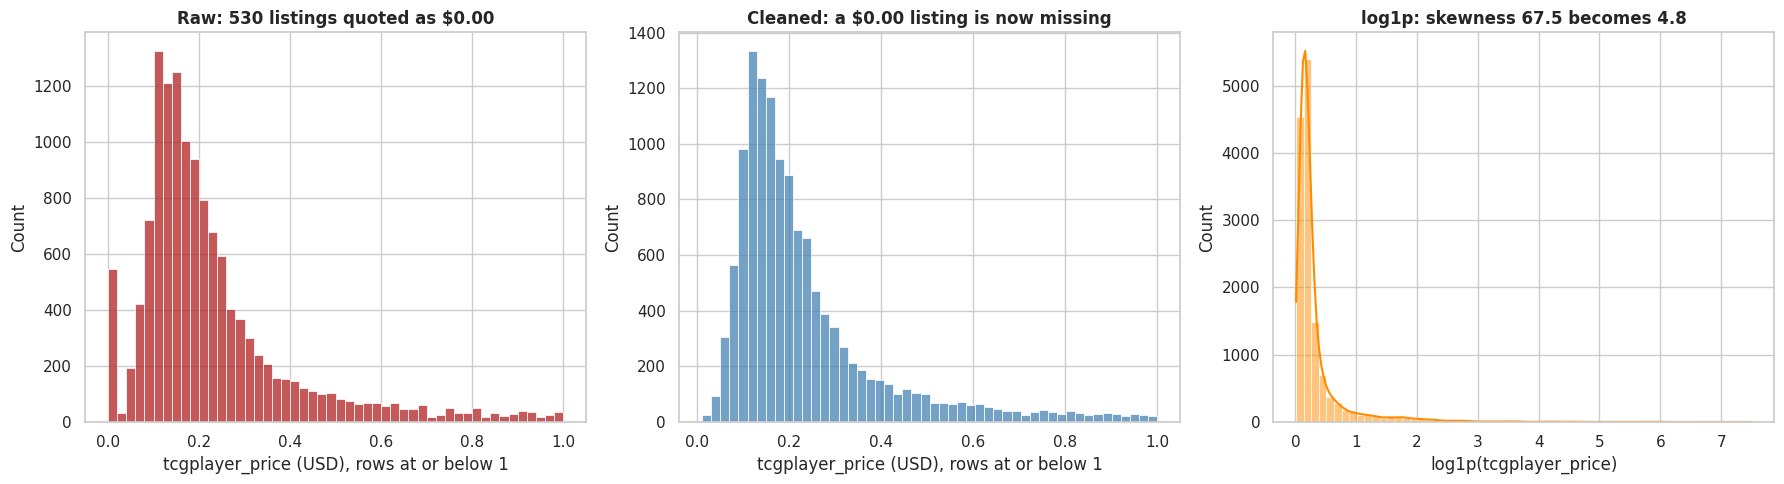

In [33]:
low_edge = 1.0

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.histplot(df.loc[df["tcgplayer_price"] <= low_edge, "tcgplayer_price"], bins=50,
             color="firebrick", edgecolor="white", ax=axes[0])
axes[0].set_title("Raw: 530 listings quoted as $0.00", fontweight="bold")
axes[0].set_xlabel("tcgplayer_price (USD), rows at or below 1")
sns.histplot(df_clean.loc[df_clean["tcgplayer_price"] <= low_edge, "tcgplayer_price"], bins=50,
             color="steelblue", edgecolor="white", ax=axes[1])
axes[1].set_title("Cleaned: a $0.00 listing is now missing", fontweight="bold")
axes[1].set_xlabel("tcgplayer_price (USD), rows at or below 1")
sns.histplot(df_clean["tcgplayer_price_log1p"].dropna(), bins=60, kde=True,
             color="darkorange", edgecolor="white", ax=axes[2])
axes[2].set_title("log1p: skewness 67.5 becomes 4.8", fontweight="bold")
axes[2].set_xlabel("log1p(tcgplayer_price)")
plt.tight_layout()
plt.savefig(cfg.OUTPUT_DIR / "preprocessing_price_transform.png", dpi=150, bbox_inches="tight")
plt.show()

The four marketplaces do not list the same cards, so a cross-market summary is added on top of the per-market prices: `n_price_sources` counts how many marketplaces quote a card, and `price_min`, `price_median` and `price_max` summarise the quotes for that card.

In [34]:
df_clean["n_price_sources"] = df_clean[price_cols].notna().sum(axis=1).astype("int64")
df_clean["price_min"] = df_clean[price_cols].min(axis=1)
df_clean["price_median"] = df_clean[price_cols].median(axis=1)
df_clean["price_max"] = df_clean[price_cols].max(axis=1)

display(df_clean[["n_price_sources", "price_min", "price_median", "price_max"]].describe().round(2))

,n_price_sources,price_min,price_median,price_max
count,14533.00,14277.00,14277.00,14277.00
mean,3.59,0.55,1.60,6.85
std,0.88,5.04,13.01,39.21
min,0.00,0.01,0.02,0.03
25%,4.00,0.07,0.21,0.99
50%,4.00,0.12,0.55,1.50
75%,4.00,0.24,0.94,3.94
max,4.00,302.89,674.99,1800.00


## Integrity Checks After Cleaning

Every rule above is verified instead of assumed. The checks confirm that the keys are unique, that no placeholder value survived, that the parsed releases still agree with `set_count`, and that the number of rows is unchanged because nothing was deleted.

In [35]:
integrity_checks = pd.Series({
    "rows in the raw frame": len(df),
    "rows in the clean frame": len(df_clean),
    "columns in the clean frame": df_clean.shape[1],
    "duplicate card_id": int(df_clean["card_id"].duplicated().sum()),
    "duplicate name": int(df_clean["name"].duplicated().sum()),
    "price still zero": int((df_clean[price_cols] == 0).sum().sum()),
    "price still negative": int((df_clean[price_cols] < 0).sum().sum()),
    "level still zero": int((df_clean["level"] == 0).sum()),
    "attack or defence still negative": int((df_clean[["atk", "def"]] < 0).sum().sum()),
    "set_count disagrees with the releases": int((df_clean["set_count"] != df_clean["n_set_entries"]).sum()),
    "cards with no price at all": int(df_clean[price_cols].isna().all(axis=1).sum()),
    "empty text cells": int(df_clean[["name", "description"]].isna().any(axis=1).sum()),
    "memory in MB": f"{df_clean.memory_usage(deep=True).sum() / 1e6:.2f}",
})
display(integrity_checks.to_frame("value"))

,value
rows in the raw frame,14533
rows in the clean frame,14533
columns in the clean frame,57
duplicate card_id,0
duplicate name,0
price still zero,0
price still negative,0
level still zero,0
attack or defence still negative,0
set_count disagrees with the releases,0


## Save the Preprocessed Dataset

The clean frame is written to `output/yugioh_cards_clean.csv` next to the set level table, so the next stage can start from these files instead of running this notebook again.

In [36]:
df_clean.to_csv(cfg.OUTPUT_DIR / "yugioh_cards_clean.csv", index=False)

written = {
    "yugioh_cards_clean.csv": df_clean.shape,
    "card_releases_long.csv": set_long.shape,
    "preprocessing_sentinels.csv": sentinel_report.shape,
}
for filename, shape in written.items():
    print(f"{cfg.OUTPUT_DIR / filename}: {shape[0]} rows x {shape[1]} columns")

/home/ryz/data/collage/sem3/datmin/Repo/Week 4/makalah/output/yugioh_cards_clean.csv: 14533 rows x 57 columns
/home/ryz/data/collage/sem3/datmin/Repo/Week 4/makalah/output/card_releases_long.csv: 44517 rows x 8 columns
/home/ryz/data/collage/sem3/datmin/Repo/Week 4/makalah/output/preprocessing_sentinels.csv: 7 rows x 4 columns


## Preprocessing Report

The raw frame of 20 analysed columns becomes a modelling-ready frame with the following groups:

- **Keys and text**: `card_id`, `name`, `description`, `desc_chars` and `desc_words`.
- **Card taxonomy**: `type`, `frame_type`, `card_kind`, `is_monster`, `is_pendulum`, `race`, `race_grouped`, `race_freq`, `attribute`, `archetype`, `archetype_grouped`, `archetype_freq`.
- **Combat statistics**: `level`, `link_value`, `atk` and `def` as nullable integers, so a spell card stays empty instead of becoming a zero.
- **Prices**: the four marketplace prices as missing-aware floats, their `log1p` versions, four whale flags, and the cross-market summary `n_price_sources`, `price_min`, `price_median` and `price_max`.
- **Releases**: `set_count`, `is_reprint`, `n_set_entries`, `n_set_codes`, `n_rarities`, `set_price_max` and `set_price_median`, with the long release table in `output/card_releases_long.csv`.
- **Ban lists**: a filled status, an ordinal severity and two flags for each of the three formats.

Four decisions are deliberate and should be kept in mind for the next stage:

1. Missing prices stay missing. No price column is imputed, because a card without a listing is not a card that is free.
2. Outliers stay in the frame. The whale cards are the signal of the collectible market, so they are transformed with `log1p` and flagged rather than removed.
3. Structural missing values stay missing. Only a flag records the reason, so a model can choose to fill the statistics per card family.
4. The card id stays a column instead of the index, so the frame can be merged with the release table and saved to CSV without losing the key.